# Retail Data Preprocessing Pipeline

Exploration, cleaning, outlier handling, transformation and splitting of the [Favorita store-sales dataset](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data) (3M+ daily sales records, 54 stores, 33 product families).

**Data:** download the CSV files into `data/` (see the README).

# 1 Data Exploration
    a. Explore the dataset by displaying the first few rows, summary statistics, and data types of each column.
    b. Identify missing values, outliers, and unique values in categorical columns.

## 1.1 store sales
### 1.1.a Explore the dataset



In [1]:
from pathlib import Path
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
import matplotlib.ticker as mtick
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
from scipy import stats

DATA_DIR = Path("data")

stores = pd.read_csv(DATA_DIR / "stores.csv",
                          names=["store_nbr", "city", "state", "type", "cluster" ],
                          header=0)

#### Oil

In [2]:
# 1. Overview


oil_df = pd.read_csv(DATA_DIR / "oil.csv", names=["date", "oil_price"], header=0, parse_dates=["date"])

print("=== Head: ===")
print(oil_df.head())

print("=== Info: ===")
print(oil_df.info())

print("=== Description: ===")
print(oil_df.describe())

=== Head: ===
        date  oil_price
0 2013-01-01        NaN
1 2013-01-02      93.14
2 2013-01-03      92.97
3 2013-01-04      93.12
4 2013-01-07      93.20
=== Info: ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1218 non-null   datetime64[ns]
 1   oil_price  1175 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.2 KB
None
=== Description: ===
                      date    oil_price
count                 1218  1175.000000
mean   2015-05-02 12:00:00    67.714366
min    2013-01-01 00:00:00    26.190000
25%    2014-03-03 06:00:00    46.405000
50%    2015-05-02 12:00:00    53.190000
75%    2016-06-30 18:00:00    95.660000
max    2017-08-31 00:00:00   110.620000
std                    NaN    25.630476


In [3]:
print("=== Time Period: ===")
print("Begin:", oil_df["date"].min(), "\nEnd:", oil_df["date"].max())
print("Tage insgesamt:", oil_df["date"].nunique())

=== Time Period: ===
Begin: 2013-01-01 00:00:00 
End: 2017-08-31 00:00:00
Tage insgesamt: 1218


#### holiday

In [4]:
holidays_df = pd.read_csv(DATA_DIR / "holidays_events.csv",
                          names=["date", "type", "local", "local-name", "description", "transferred", ],
                          header=0, parse_dates=["date"])

print("=== Head: ===")
print(holidays_df.head())

print("=== Info: ===")
print(holidays_df.info())

print("=== Description: ===")
print(holidays_df.describe())

=== Head: ===
        date     type     local local-name                    description  \
0 2012-03-02  Holiday     Local      Manta             Fundacion de Manta   
1 2012-04-01  Holiday  Regional   Cotopaxi  Provincializacion de Cotopaxi   
2 2012-04-12  Holiday     Local     Cuenca            Fundacion de Cuenca   
3 2012-04-14  Holiday     Local   Libertad      Cantonizacion de Libertad   
4 2012-04-21  Holiday     Local   Riobamba      Cantonizacion de Riobamba   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False  
=== Info: ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         350 non-null    datetime64[ns]
 1   type         350 non-null    object        
 2   local        350 non-null    object        
 3   local-name   350 non-null    object        
 4   desc

In [5]:
# 2. Missing Values
print("=== How much NAs per Col: ===")
print(holidays_df.isnull().sum())

=== How much NAs per Col: ===
date           0
type           0
local          0
local-name     0
description    0
transferred    0
dtype: int64


#### Sample submission


In [6]:
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv",
                          names=["id", "sales" ],
                          header=0)

print("=== Head: ===")
print(sample_submission.head())

print("=== Info: ===")
print(sample_submission.info())

print("=== Description: ===")
print(sample_submission.describe())

=== Head: ===
        id  sales
0  3000888    0.0
1  3000889    0.0
2  3000890    0.0
3  3000891    0.0
4  3000892    0.0
=== Info: ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      28512 non-null  int64  
 1   sales   28512 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 445.6 KB
None
=== Description: ===
                 id    sales
count  2.851200e+04  28512.0
mean   3.015144e+06      0.0
std    8.230850e+03      0.0
min    3.000888e+06      0.0
25%    3.008016e+06      0.0
50%    3.015144e+06      0.0
75%    3.022271e+06      0.0
max    3.029399e+06      0.0


#### Stores

In [7]:


print("=== Head: ===")
print(stores.head())

print("=== Info: ===")
print(stores.info())

print("=== Description: ===")
print(stores.describe())

=== Head: ===
   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4
=== Info: ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB
None
=== Description: ===
       store_nbr    cluster
count  54.000000  54.000000
mean   27.500000   8.

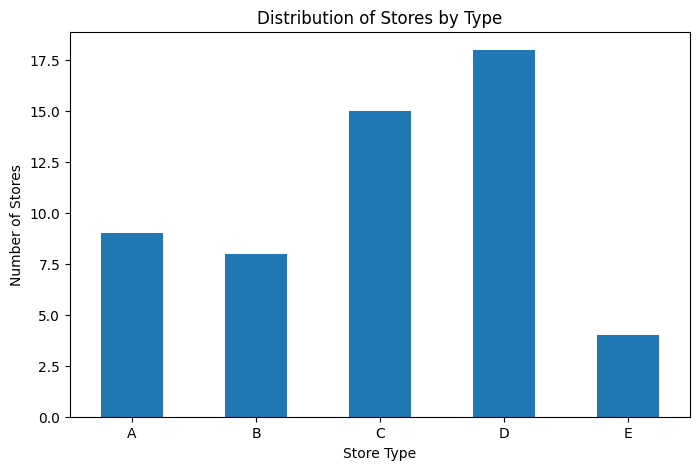

In [8]:

store_counts = stores['type'].value_counts().sort_index()

plt.figure(figsize=(8,5))
store_counts.plot(kind='bar')
plt.title("Distribution of Stores by Type")
plt.xlabel("Store Type")
plt.ylabel("Number of Stores")
plt.xticks(rotation=0)
plt.show()


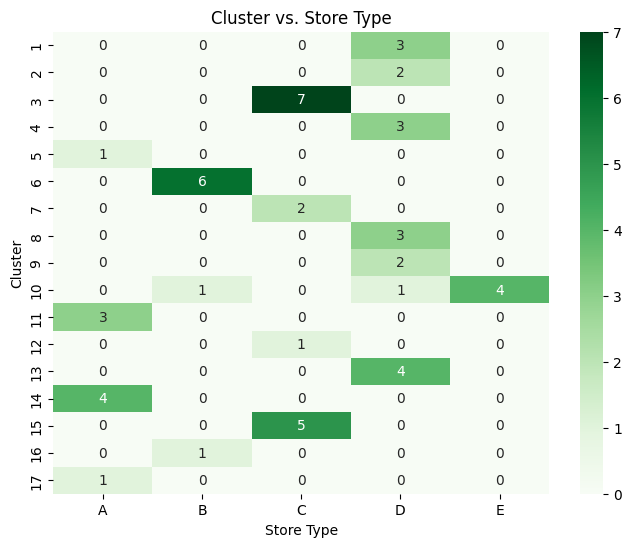

In [9]:


cluster_type_ct = pd.crosstab(stores['cluster'], stores['type'])
plt.figure(figsize=(8,6))
sns.heatmap(cluster_type_ct, annot=True, fmt="d", cmap="Greens")
plt.title("Cluster vs. Store Type")
plt.ylabel("Cluster")
plt.xlabel("Store Type")
plt.show()


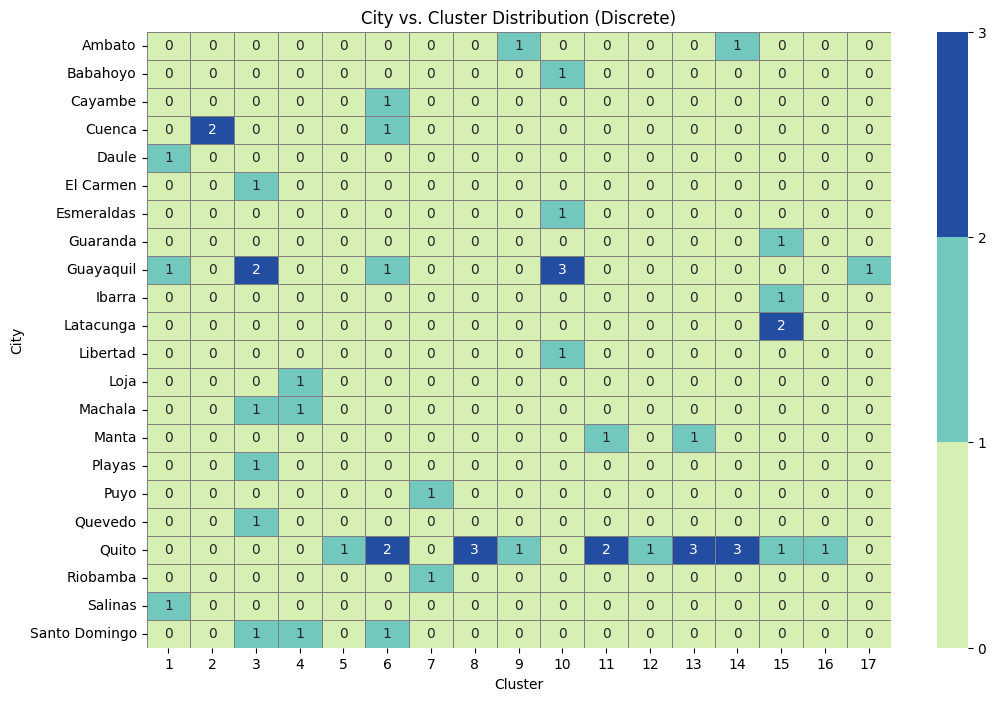

In [10]:


city_cluster_ct = pd.crosstab(stores['city'], stores['cluster'])

values = range(int(city_cluster_ct.values.max()) + 1)
cmap = ListedColormap(sns.color_palette("YlGnBu", len(values)))
norm = BoundaryNorm(values, cmap.N)

plt.figure(figsize=(12,8))
sns.heatmap(
    city_cluster_ct,
    cmap=cmap,
    norm=norm,
    cbar=True,
    linewidths=0.5,
    linecolor="gray",
    annot=True, fmt="d"
)
plt.title("City vs. Cluster Distribution (Discrete)")
plt.ylabel("City")
plt.xlabel("Cluster")
plt.show()


#### transaction


In [11]:
transaction_df = pd.read_csv(DATA_DIR / "transactions.csv",
                          names=["date", "store_nbr", "transaction" ],
                          header=0, parse_dates=["date"])

print("=== Head: ===")
print(transaction_df.head())

print("=== Info: ===")
print(transaction_df.info())

print("=== Description: ===")
print(transaction_df.describe())

=== Head: ===
        date  store_nbr  transaction
0 2013-01-01         25          770
1 2013-01-02          1         2111
2 2013-01-02          2         2358
3 2013-01-02          3         3487
4 2013-01-02          4         1922
=== Info: ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         83488 non-null  datetime64[ns]
 1   store_nbr    83488 non-null  int64         
 2   transaction  83488 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.9 MB
None
=== Description: ===
                                date     store_nbr   transaction
count                          83488  83488.000000  83488.000000
mean   2015-05-20 16:07:40.866232064     26.939237   1694.602158
min              2013-01-01 00:00:00      1.000000      5.000000
25%              2014-03-27 00:00:00     13.000000   1

In [12]:
# count unique store_nbr
transaction_df['store_nbr'].nunique()

54

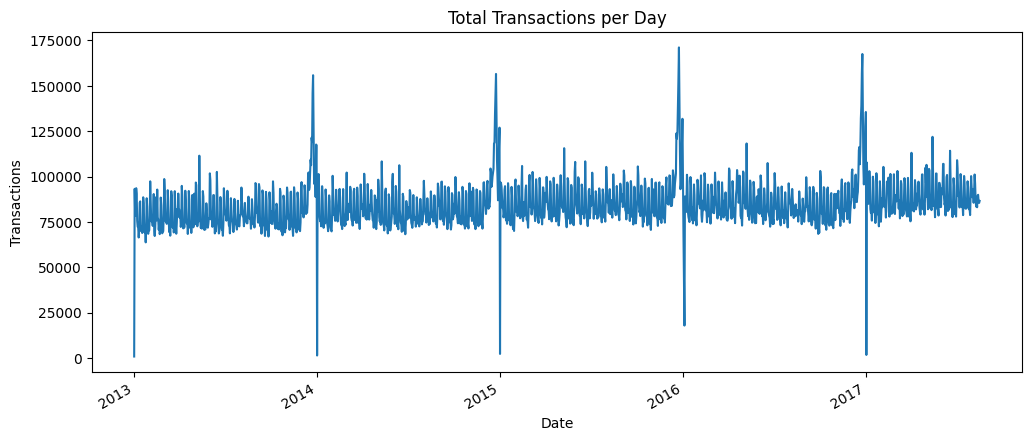

In [13]:
transactions_per_day = transaction_df.groupby('date')['transaction'].sum()


plt.figure(figsize=(12,5))
transactions_per_day.plot()
plt.title("Total Transactions per Day")
plt.xlabel("Date")
plt.ylabel("Transactions")
plt.show()

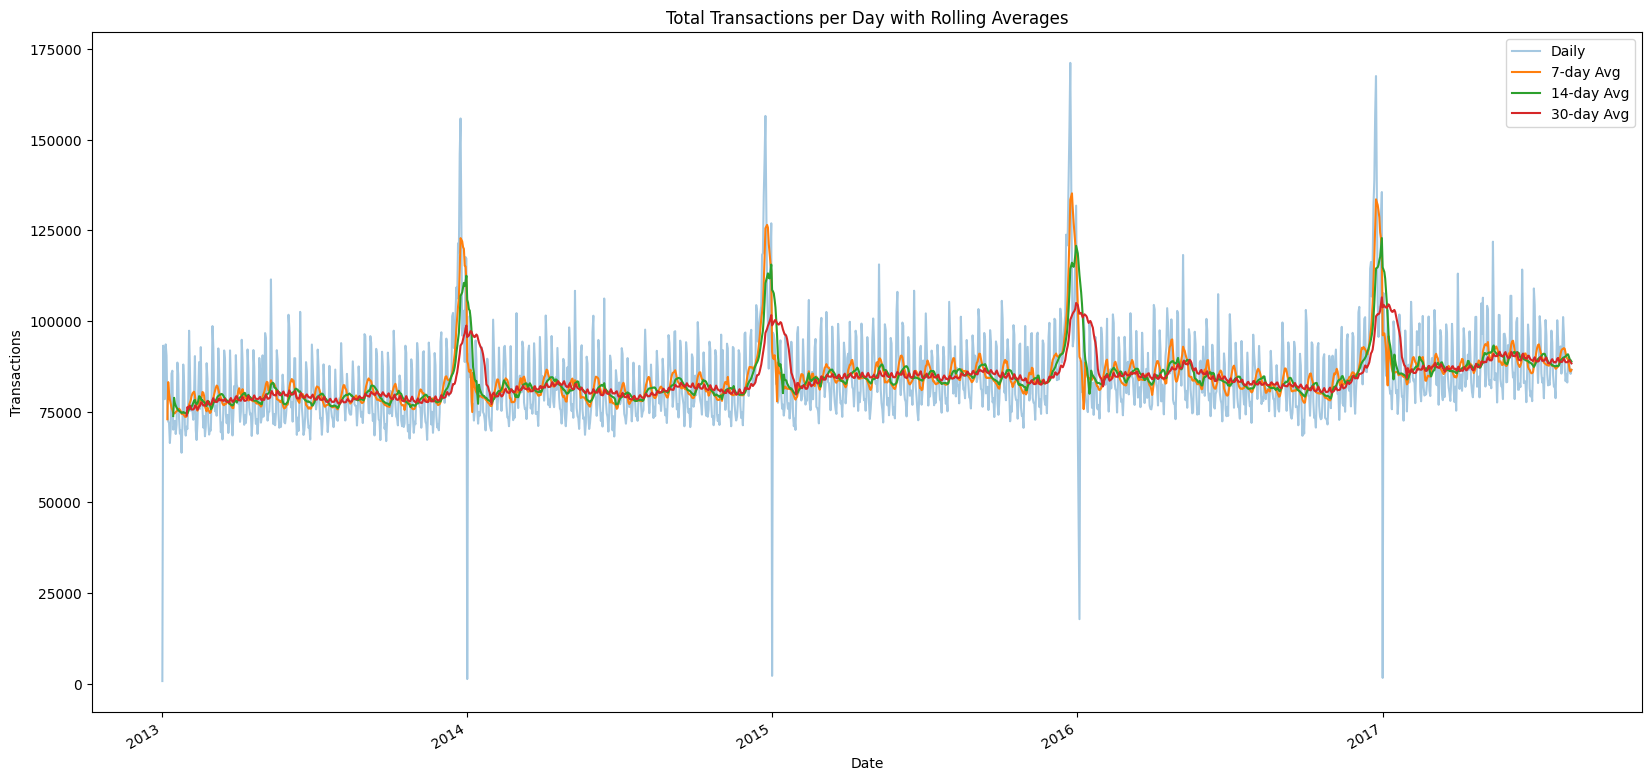

In [14]:
plt.figure(figsize=(20,10))
transactions_per_day.plot(alpha=0.4, label="Daily")
transactions_per_day.rolling(7).mean().plot(label="7-day Avg")
transactions_per_day.rolling(14).mean().plot(label="14-day Avg")
transactions_per_day.rolling(30).mean().plot(label="30-day Avg")
plt.title("Total Transactions per Day with Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Transactions")
plt.legend()
plt.show()


#### Train/ Test

In [15]:
train_df = pd.read_csv(DATA_DIR / "train.csv",
                          names=["id", "date", "store_nbr", "family","sales", "onpromotion" ],
                          header=0, parse_dates=["date"])

print("=== Head: ===")
print(train_df.head())

print("=== Info: ===")
print(train_df.info())

print("=== Description: ===")
print(train_df.describe())

=== Head: ===
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0
=== Info: ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB
None
=== Description: ===


                 id                           date     store_nbr  \
count  3.000888e+06                        3000888  3.000888e+06   
mean   1.500444e+06  2015-04-24 08:27:04.703088384  2.750000e+01   
min    0.000000e+00            2013-01-01 00:00:00  1.000000e+00   
25%    7.502218e+05            2014-02-26 18:00:00  1.400000e+01   
50%    1.500444e+06            2015-04-24 12:00:00  2.750000e+01   
75%    2.250665e+06            2016-06-19 06:00:00  4.100000e+01   
max    3.000887e+06            2017-08-15 00:00:00  5.400000e+01   
std    8.662819e+05                            NaN  1.558579e+01   

              sales   onpromotion  
count  3.000888e+06  3.000888e+06  
mean   3.577757e+02  2.602770e+00  
min    0.000000e+00  0.000000e+00  
25%    0.000000e+00  0.000000e+00  
50%    1.100000e+01  0.000000e+00  
75%    1.958473e+02  0.000000e+00  
max    1.247170e+05  7.410000e+02  
std    1.101998e+03  1.221888e+01  


In [16]:
train_df['family'].nunique()

33

In [17]:
# missing values
train_df.isna().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

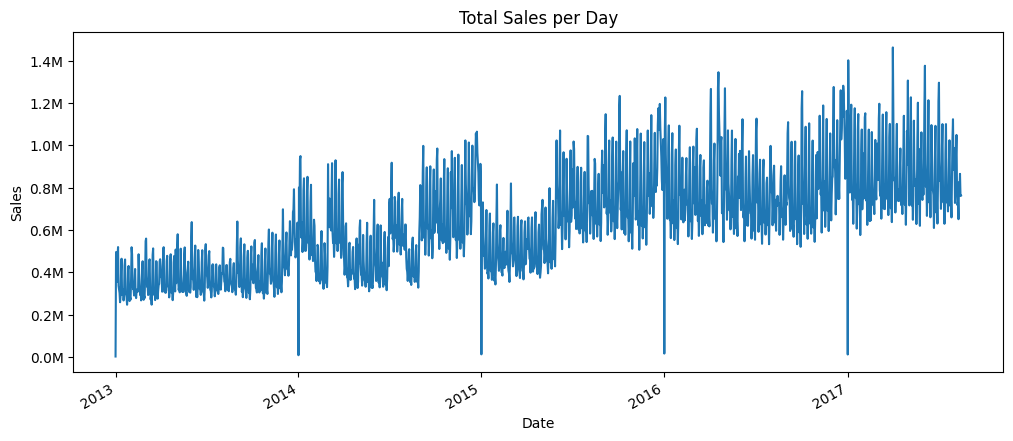

In [18]:

daily_sales = train_df.groupby('date')['sales'].sum()

plt.figure(figsize=(12,5))
ax = daily_sales.plot()

# values into millions
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{float(x/1e6)}M'))

plt.title("Total Sales per Day")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()



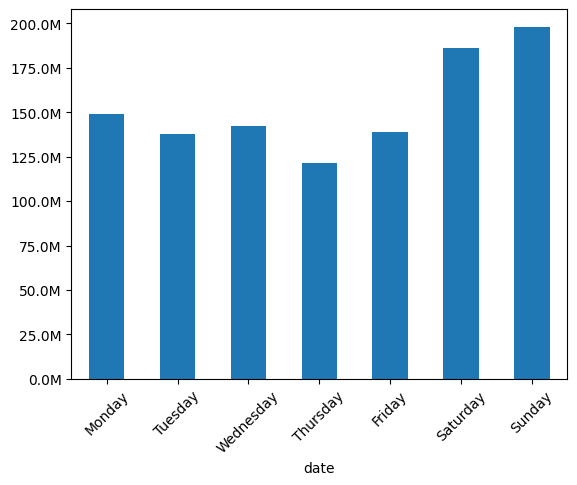

In [19]:

weekday_sales = train_df.groupby(train_df['date'].dt.day_name())['sales'].sum()

# define order fpr weekdays
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_sales = weekday_sales.reindex(order)

# values into millions
ax = weekday_sales.plot.bar()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{float(x/1e6)}M'))
ax.xaxis.set_tick_params(rotation=45)


### 1.1.b Identifiy missing data and outliers

#### missing data

In [20]:
# Missing oil
print("=== How much NAs per Col: ===")
print(oil_df.isnull().sum())

=== How much NAs per Col: ===
date          0
oil_price    43
dtype: int64


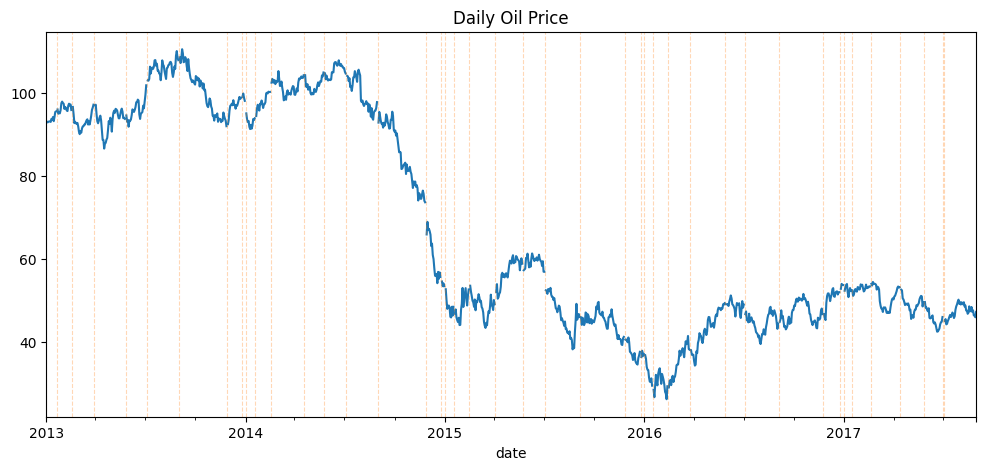

In [21]:
# Visualization to missing oil data:
import matplotlib.pyplot as plt
s = oil_df.set_index("date")["oil_price"]

fig, ax = plt.subplots(figsize=(12,5))
s.plot(ax=ax)

for x in s.index[s.isna()]:
    ax.axvline(x, linestyle="--", linewidth=0.8, alpha=0.3, color="tab:orange")

ax.set_title("Daily Oil Price")
plt.show()

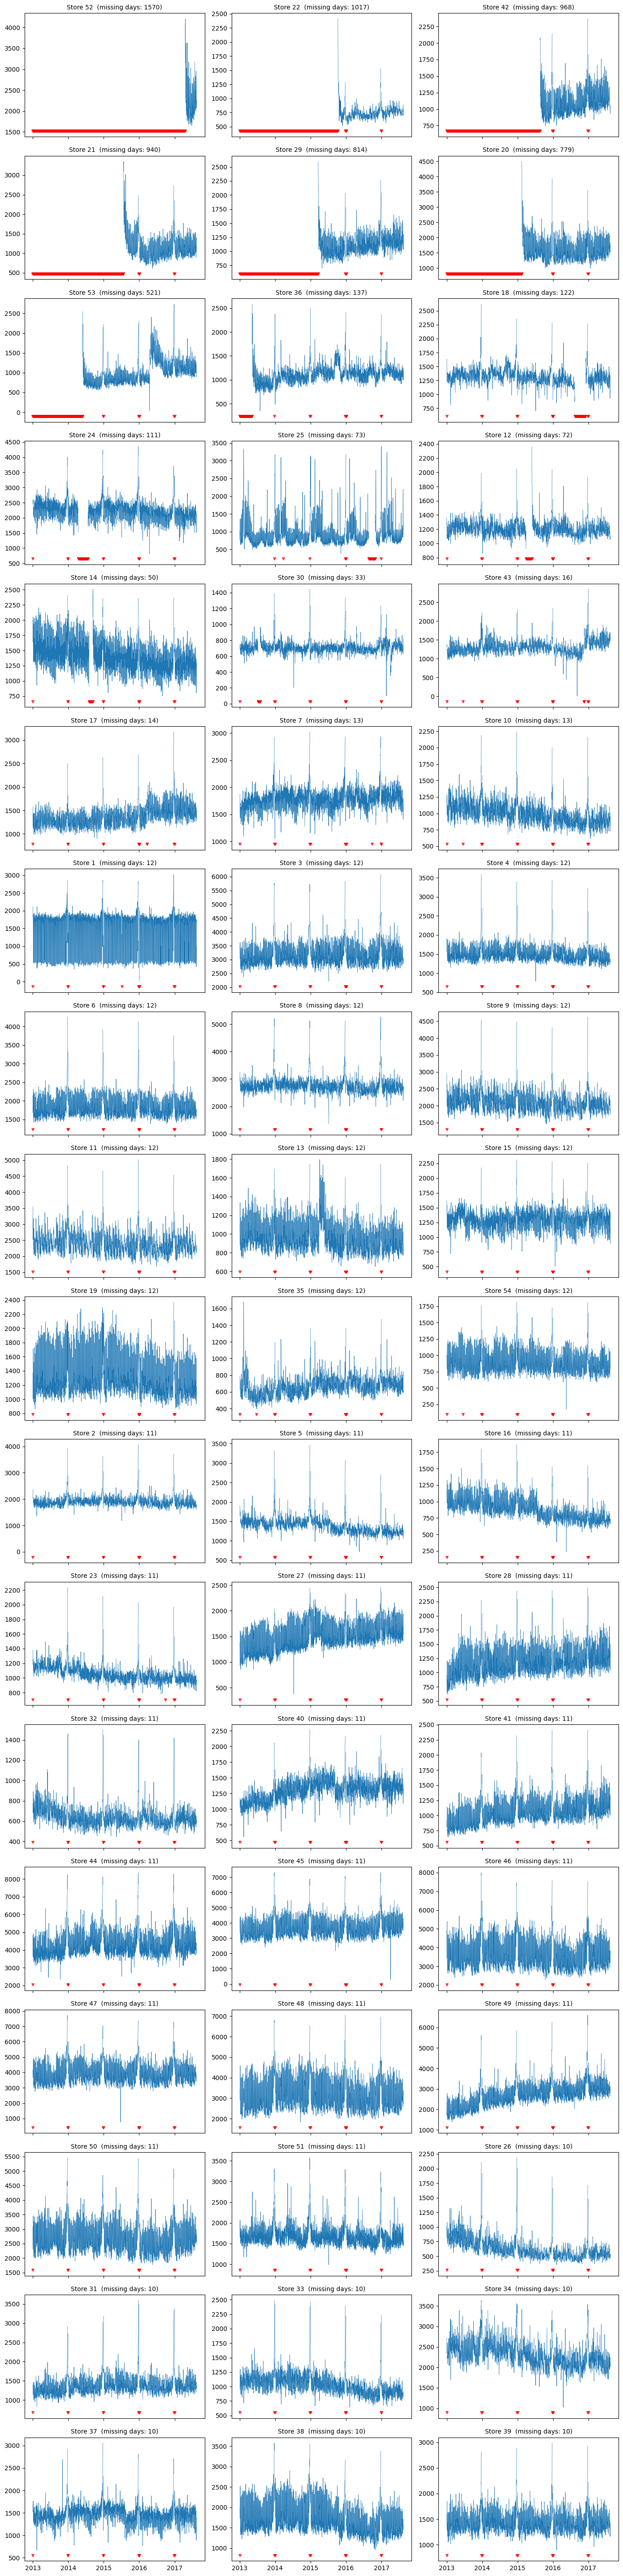

In [22]:
tpd = (transaction_df
       .groupby(['store_nbr', 'date'], as_index=False)['transaction']
       .sum()
       .sort_values(['store_nbr', 'date']))
tpd['date'] = pd.to_datetime(tpd['date']).dt.normalize()


full_idx = pd.date_range(tpd['date'].min(), tpd['date'].max(), freq='D')


dates_by_store = tpd.groupby('store_nbr')['date'].unique()
missing_counts = {s: len(full_idx.difference(pd.DatetimeIndex(dates)))
                  for s, dates in dates_by_store.items()}
stores_with_gaps = [s for s, cnt in missing_counts.items() if cnt > 0]

stores_to_plot = sorted(stores_with_gaps, key=lambda s: missing_counts[s], reverse=True)

# Subplots
n = len(stores_to_plot)
cols = 3 if n > 1 else 1
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 3.2*rows), sharex=True)
axes = axes.flatten() if n > 1 else [axes]

for ax, s in zip(axes, stores_to_plot):
    sdf = (tpd[tpd['store_nbr'] == s]
           .set_index('date')
           .reindex(full_idx))
    ax.plot(sdf.index, sdf['transaction'], linewidth=0.5)

    miss = sdf['transaction'].isna()
    if miss.any():
        ymin, ymax = ax.get_ylim()
        ax.scatter(sdf.index[miss], [ymin]*miss.sum(), marker='v', s=16, alpha=0.7, color="red")
    ax.set_title(f"Store {s}  (missing days: {missing_counts[s]})", fontsize=10)

for ax in axes[n:]:
    ax.axis('off')

fig.tight_layout()
plt.show()


Most stores have 10-12 days missing around Christmas/ New Year, but some stores have a lot more missing data.

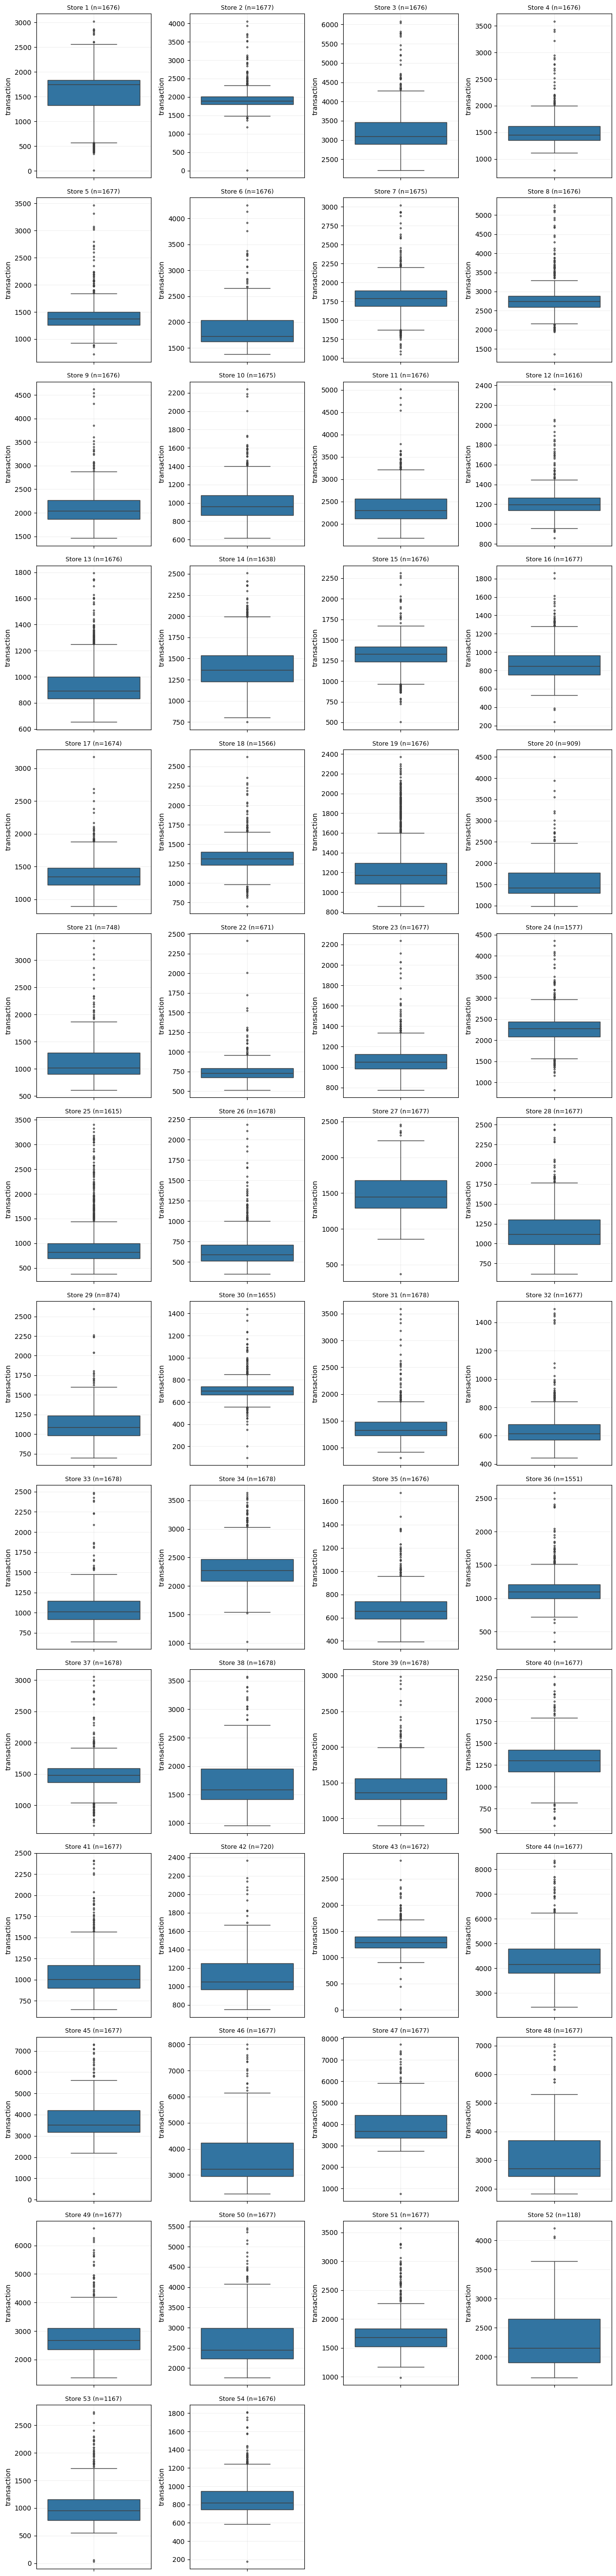

In [23]:
tpd_df = transaction_df.copy()
tpd_df['date'] = pd.to_datetime(tpd_df['date']).dt.normalize()

tpd = (tpd_df
       .groupby(['store_nbr', 'date'], as_index=False)['transaction']
       .sum()
       .sort_values(['store_nbr', 'date']))


stores_to_plot = sorted(tpd['store_nbr'].unique().tolist())


n = len(stores_to_plot)
cols = 4 if n >= 12 else 3 if n >= 6 else 2 if n > 1 else 1
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(3.2*cols, 3.8*rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, store in zip(axes, stores_to_plot):
    svals = tpd.loc[tpd['store_nbr'] == store, 'transaction']
    sns.boxplot(y=svals, ax=ax, fliersize=2)
    ax.set_title(f"Store {store} (n={svals.notna().sum()})", fontsize=9)
    ax.grid(True, alpha=0.2)

for ax in axes[len(stores_to_plot):]:
    ax.axis('off')

fig.tight_layout()
plt.show()


Looks like there are outliers in every store transaction.

# 2 Data Cleaning
    a. Handling Missing Values
    b. Choose appropriate methods to handle missing values (e.g., mean/median imputation for numerical data, mode imputation for categorical data, or deletion of rows/columns).
    c. Justify your choices for handling missing data.

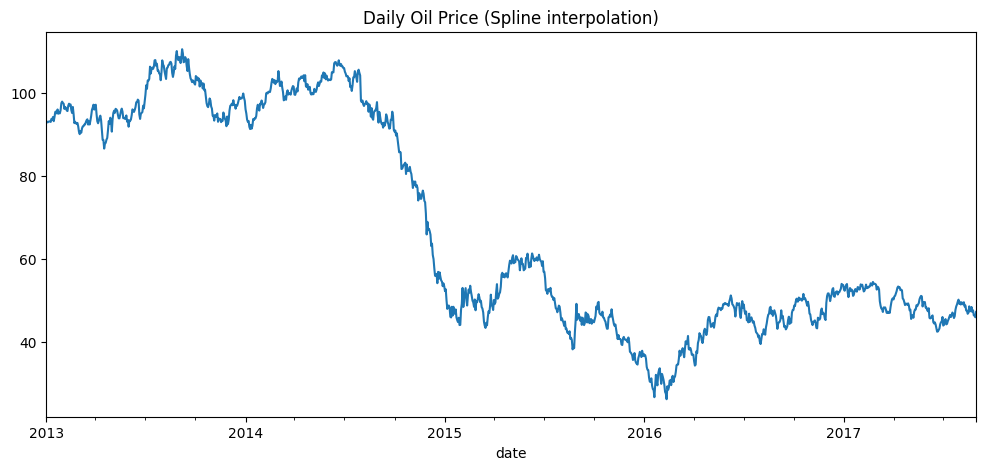

In [24]:
oil_df['date'] = pd.to_datetime(oil_df['date'])
oil_df = oil_df.sort_values('date')


oil_df['oil_price'] = oil_df['oil_price'].interpolate(
    method="spline", order=5
)

s = oil_df.set_index("date")["oil_price"]

fig, ax = plt.subplots(figsize=(12,5))
s.plot(ax=ax)


ax.set_title("Daily Oil Price (Spline interpolation)")
plt.show()


In our dataset, only a few short gaps in the oil price data occurred. Since oil prices typically evolve continuously over time without abrupt jumps, interpolation is a suitable approach in this context. We chose spline interpolation because it produces smoother transitions than linear interpolation and thus reflects the economic trajectory more realistically. This allows us to fill the missing values consistently without significantly distorting the statistical properties of the series.

In [25]:
# handle missing data in store

# implement holiday feature to explain missing data
"""
    is_holiday 1: holiday.type in {holiday, additonal, bridge, Event} && holiday.transfered == false && holiday.locale == National
    is_holiday 1: holiday.type in {holiday, additonal, bridge, Event} && holiday.transfered == false && (holiday.locale == Regional && stores[transactions.str_nbr].state ==  holiday.locale_name)
    is_holiday 1: holiday.type in {holiday, additonal, bridge, Event} && holiday.transfered == false && (holiday.locale == Local && stores[transactions.str_nbr].city ==  holiday.locale_name)

    is_holiday 0: holiday.type == workday || holiday.transfered == true
    is_holiday 0: default with no holiday in the file

    is_holiday 1: holiday.type == Transfered

    => holiday.type == Transfered :: holiday.type to holiday
    => holiday.transfered == true :: holiday.type to workday
"""

transactions = pd.read_csv(DATA_DIR / "transactions.csv",
                          names=["date", "store_nbr", "transaction" ],
                          header=0, parse_dates=["date"])

holidays = pd.read_csv(DATA_DIR / "holidays_events.csv",
                          names=["date", "type", "locale", "locale_name", "description", "transferred", ],
                          header=0, parse_dates=["date"])

stores = pd.read_csv(DATA_DIR / "stores.csv",
                          names=["store_nbr", "city", "state", "type", "cluster" ],
                          header=0)


transactions['date'] = pd.to_datetime(transactions['date']).dt.normalize()
holidays['date'] = pd.to_datetime(holidays['date']).dt.normalize()

# delete an value:
transactions = transactions[transactions['date'] != pd.to_datetime("2013-01-01")]
transactions_grouped = (transactions
                            .groupby(['store_nbr', 'date'], as_index=False)['transaction']
                            .sum()
                            .sort_values(['store_nbr', 'date']))

# holidays preprocessing
holidays_clean = holidays.copy()

# transfers: make them Holiday
holidays_clean.loc[holidays_clean['type'] == "Transfer", 'type'] = "Holiday"

# transferred==True → make them Work Day
holidays_clean.loc[holidays_clean['transferred'] == True, 'type'] = "Work Day"

# join holidays onto transactions
df = transactions_grouped.merge(stores, on="store_nbr", how="left")

# add holiday info
df = df.merge(holidays_clean[['date','type','locale','locale_name','transferred']],
              on="date", how="left",

              suffixes=("", "_holiday"))


# default: no holiday
df['is_holiday'] = 0

# rule 1: national holiday
mask_nat = (df['type_holiday'].isin(["Holiday","Additional","Bridge"])) & (df['locale']=="National")
df.loc[mask_nat, 'is_holiday'] = 1

# rule 2: regional holiday
mask_reg = (df['type_holiday'].isin(["Holiday","Additional","Bridge"])) & (df['locale']=="Regional") & (df['state']==df['locale_name'])
df.loc[mask_reg, 'is_holiday'] = 1

# rule 3: local holiday
mask_loc = (df['type_holiday'].isin(["Holiday","Additional","Bridge"])) & (df['locale']=="Local") & (df['city']==df['locale_name'])
df.loc[mask_loc, 'is_holiday'] = 1

# remove city, state, type, cluster, type_holiday, locale, locale_name, transferred

df = df[['date','store_nbr','transaction','is_holiday']]
print(df.tail(20))


            date  store_nbr  transaction  is_holiday
84986 2017-07-27         54          662           0
84987 2017-07-28         54          766           0
84988 2017-07-29         54          870           0
84989 2017-07-30         54         1108           0
84990 2017-07-31         54          860           0
84991 2017-08-01         54          841           0
84992 2017-08-02         54          747           0
84993 2017-08-03         54          712           0
84994 2017-08-04         54          757           0
84995 2017-08-05         54          867           0
84996 2017-08-06         54         1065           0
84997 2017-08-07         54          842           0
84998 2017-08-08         54          752           0
84999 2017-08-09         54          748           0
85000 2017-08-10         54          670           0
85001 2017-08-11         54          768           1
85002 2017-08-12         54          903           0
85003 2017-08-13         54         1054      

In [26]:
# Build store open feature
"""
    store_open 0: store is closed if data is missing for more than 10 continuing days
        => add a transaction on dates with 0
    store_open 1: store is open if data is available for at least 10 continuing days
"""
global_start = df['date'].min()
global_end   = df['date'].max()

full_cal = []
for s in df['store_nbr'].unique():
    g = (df.loc[df['store_nbr'] == s, ['date','transaction','is_holiday']]
           .copy()
           .sort_values('date'))

    g = (g.groupby('date', as_index=False)
           .agg(transaction=('transaction','sum'),
                is_holiday =('is_holiday','max')))

    idx = pd.DataFrame({'date': pd.date_range(global_start, global_end, freq='D')})
    g_full = idx.merge(g, on='date', how='left')

    g_full['store_nbr'] = s

    # Holiday-Flag for added days
    g_full['is_holiday'] = g_full['is_holiday'].fillna(0).astype(int)

    full_cal.append(g_full)

df_full = pd.concat(full_cal, ignore_index=True)


def run_mask(series, cond, min_len=10):
    m = cond(series)
    grp = (m != m.shift()).cumsum()
    runlen = m.groupby(grp).transform('size')
    return m & (runlen >= min_len)

df_full = df_full.sort_values(['store_nbr','date'])

open_run = (df_full.groupby('store_nbr')['transaction']
                  .apply(lambda s: run_mask(s, pd.Series.notna, min_len=10))
                  .reset_index(level=0, drop=True))

closed_run = (df_full.groupby('store_nbr')['transaction']
                    .apply(lambda s: run_mask(s, pd.Series.isna, min_len=10))
                    .reset_index(level=0, drop=True))
df_full['store_open'] = np.where(open_run, 1,
                          np.where(closed_run, 0, np.nan))

df_full['store_open'] = (
    df_full
      .groupby('store_nbr', group_keys=False)['store_open']
      .apply(lambda s: s.ffill().bfill())
      .fillna(0)
      .astype(int)
)

df_full.loc[(df_full['store_open']==0) & (df_full['transaction'].isna()), 'transaction'] = 0

def interp_per_store(g, max_gap=5):
    g = g.sort_values('date').set_index('date')
    allowed = (g['store_open'] == 1) & (g['is_holiday'] == 0)
    y = g['transaction'].copy()
    # only interpolate allowed data
    y_allowed = y.where(allowed)
    y_filled = y_allowed.interpolate(method='time',
                                     limit=max_gap,
                                     limit_area='inside')
    g.loc[allowed & y.isna(), 'transaction'] = y_filled
    return g.reset_index()

df_full = df_full.groupby('store_nbr', group_keys=False).apply(interp_per_store, max_gap=5)

print(df_full.tail(20))

           date  transaction  is_holiday  store_nbr  store_open
1667 2017-07-27        662.0           0         54           1
1668 2017-07-28        766.0           0         54           1
1669 2017-07-29        870.0           0         54           1
1670 2017-07-30       1108.0           0         54           1
1671 2017-07-31        860.0           0         54           1
1672 2017-08-01        841.0           0         54           1
1673 2017-08-02        747.0           0         54           1
1674 2017-08-03        712.0           0         54           1
1675 2017-08-04        757.0           0         54           1
1676 2017-08-05        867.0           0         54           1
1677 2017-08-06       1065.0           0         54           1
1678 2017-08-07        842.0           0         54           1
1679 2017-08-08        752.0           0         54           1
1680 2017-08-09        748.0           0         54           1
1681 2017-08-10        670.0           0

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22764\1443891518.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_full = df_full.groupby('store_nbr', group_keys=False).apply(interp_per_store, max_gap=5)


### Data Cleaning – Transactions

- A single value (2013-01-01) was removed, since data was only available for one store.
- Holiday data was integrated and marked with `is_holiday` to explain transaction peaks.
- A complete daily calendar was built for each store and `store_open` was derived:
  - `0` if ≥10 consecutive days without data (closed, transactions = 0).
  - `1` if ≥10 consecutive days with data (open).
- Missing values in open, non-holiday phases were only interpolated for short gaps (≤5 days) using time-based interpolation.

➡️ This way, real closures and events remain intact, while small gaps are handled consistently.


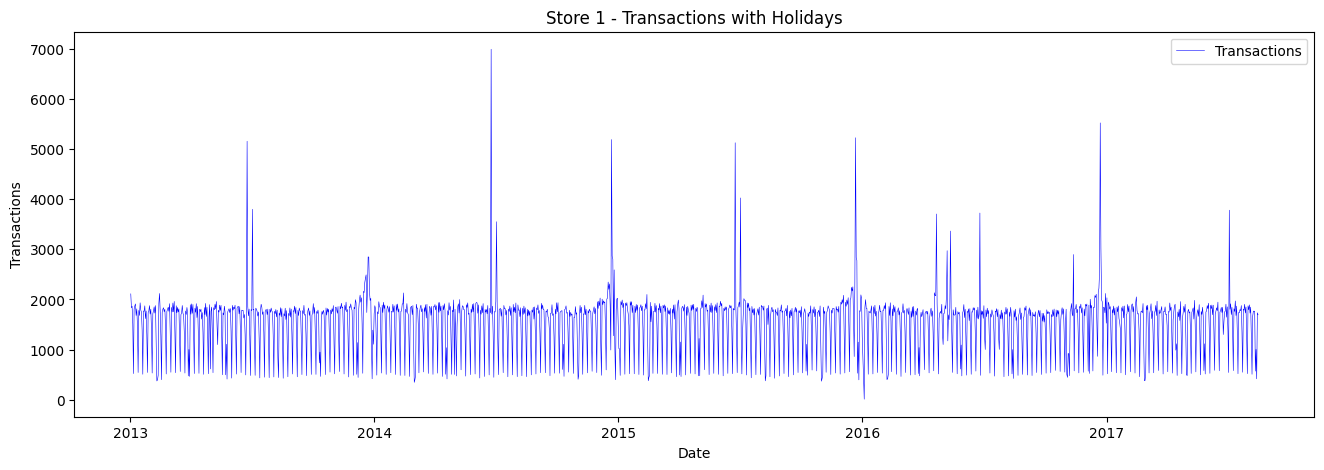

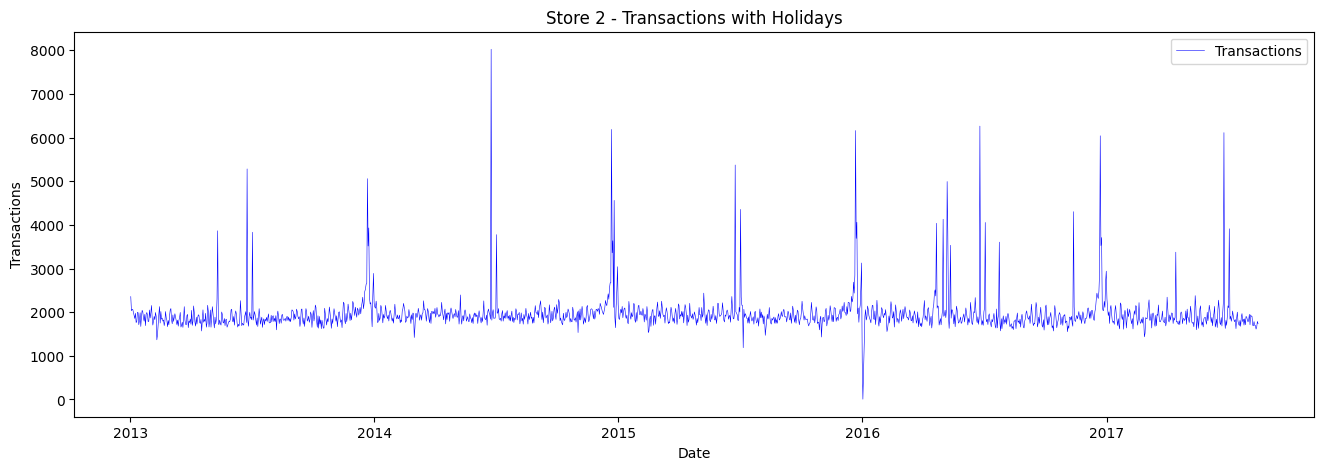

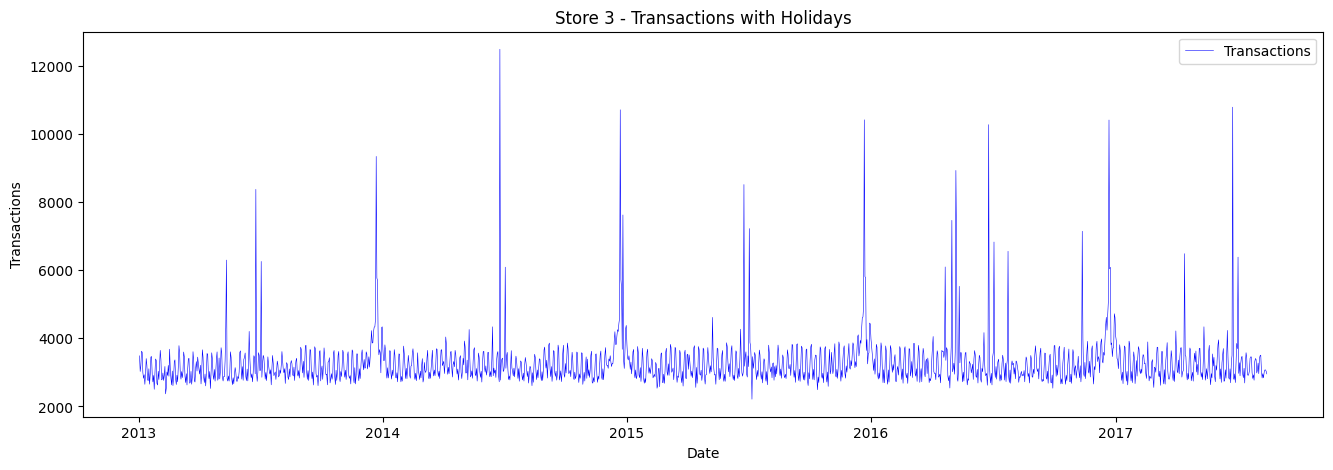

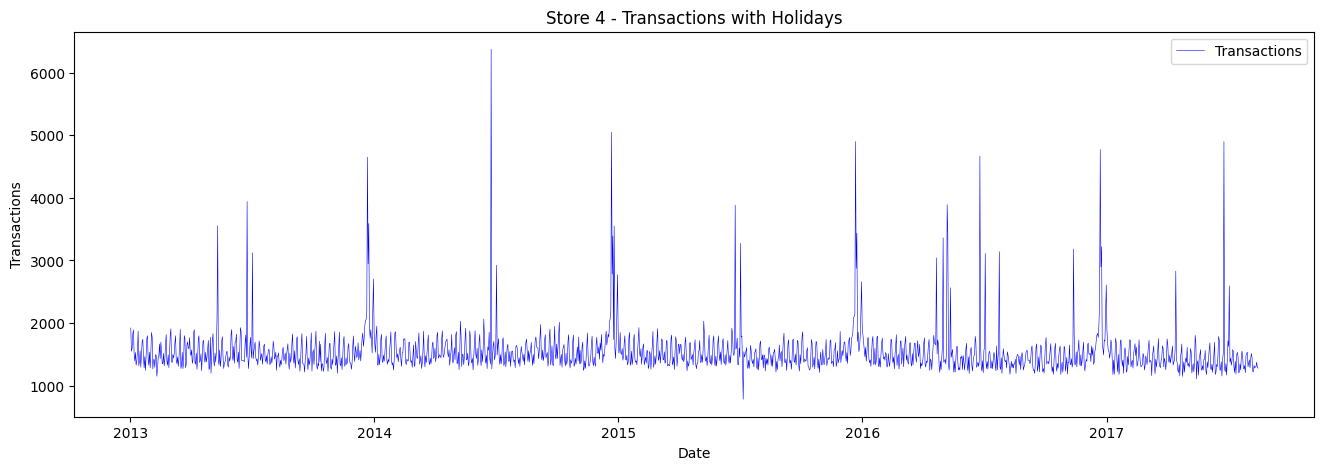

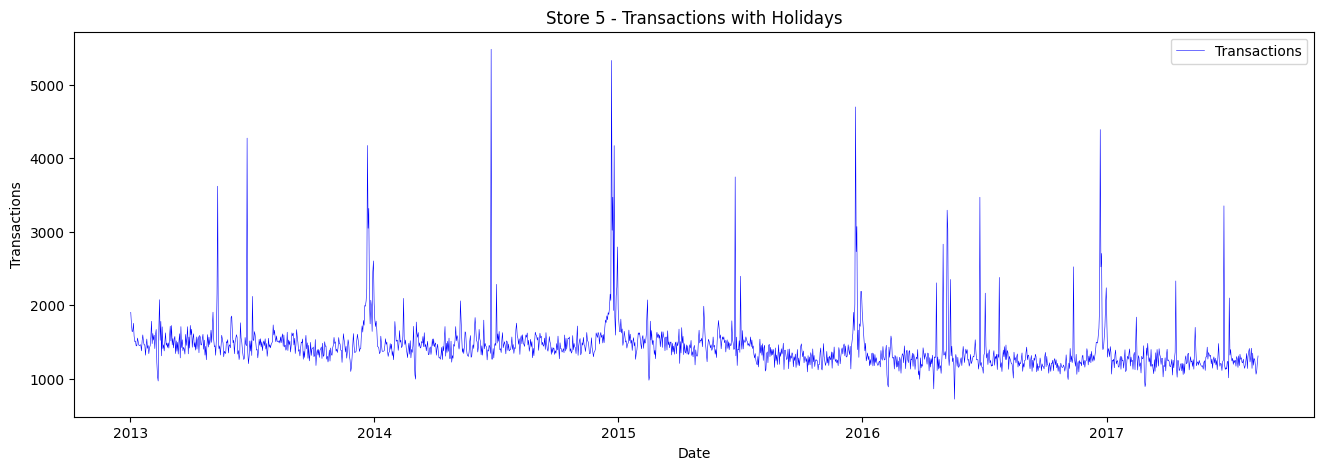

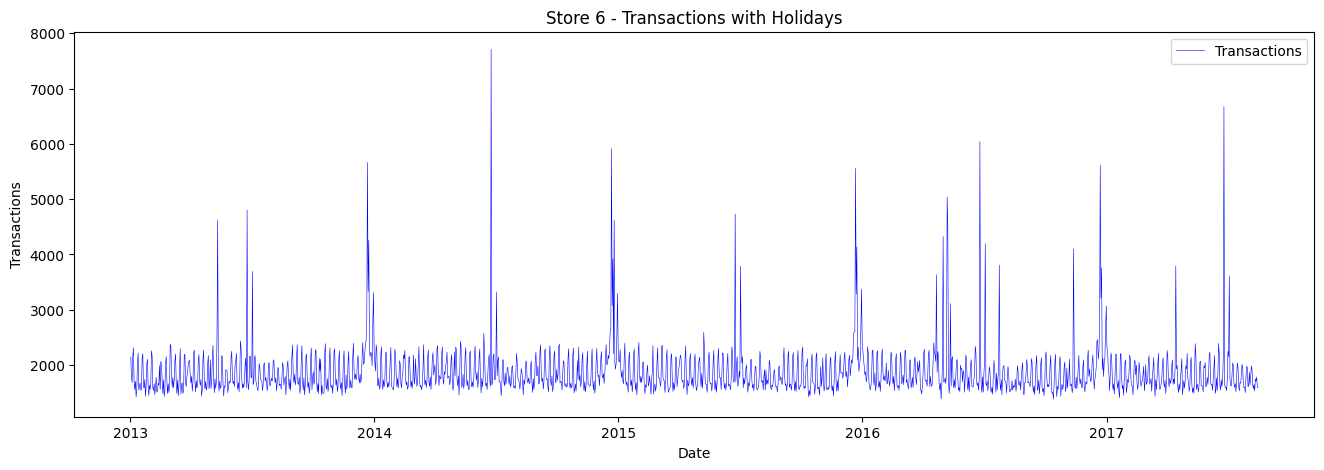

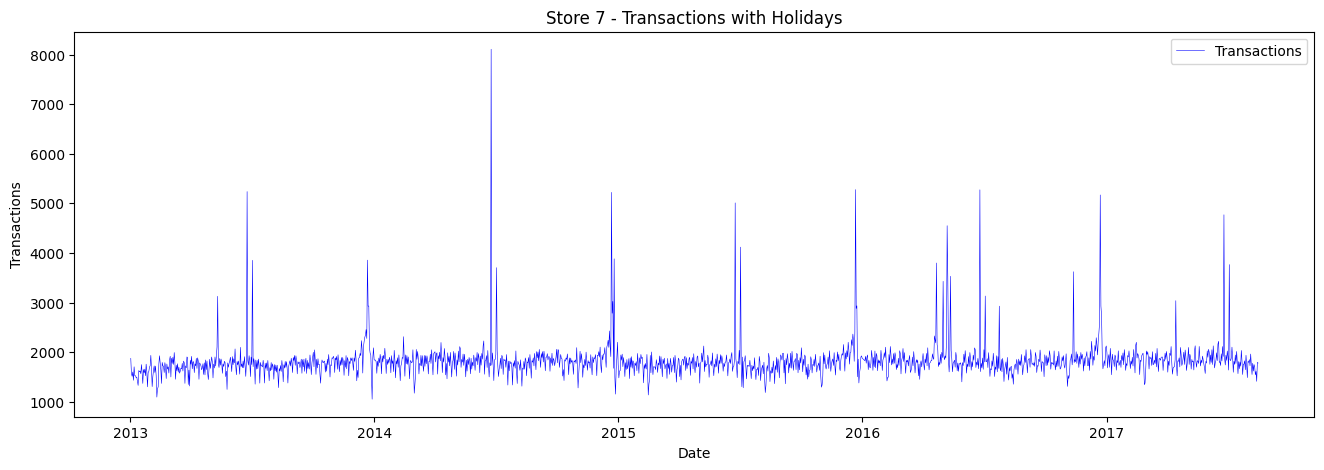

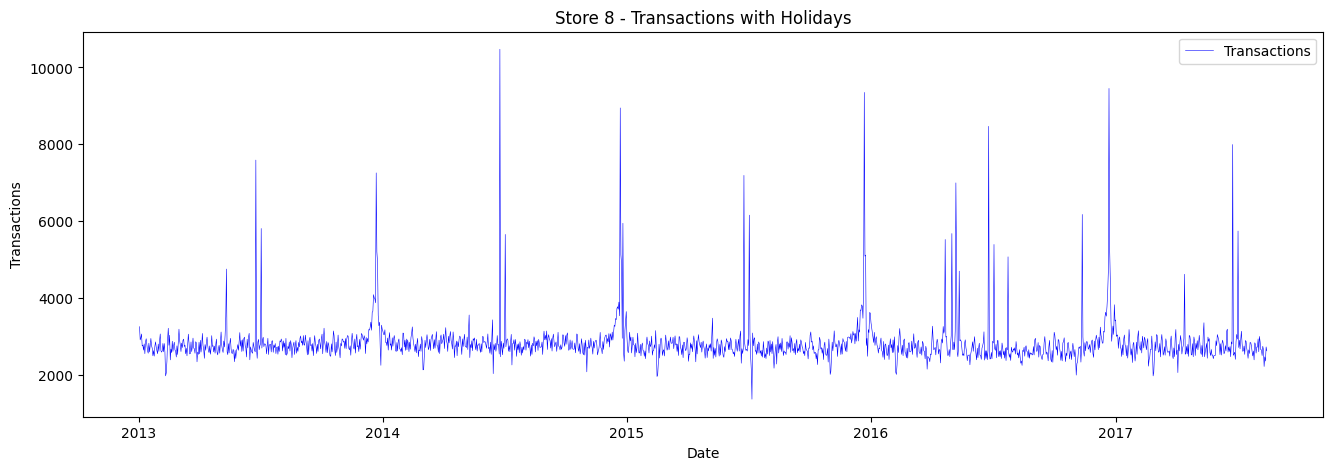

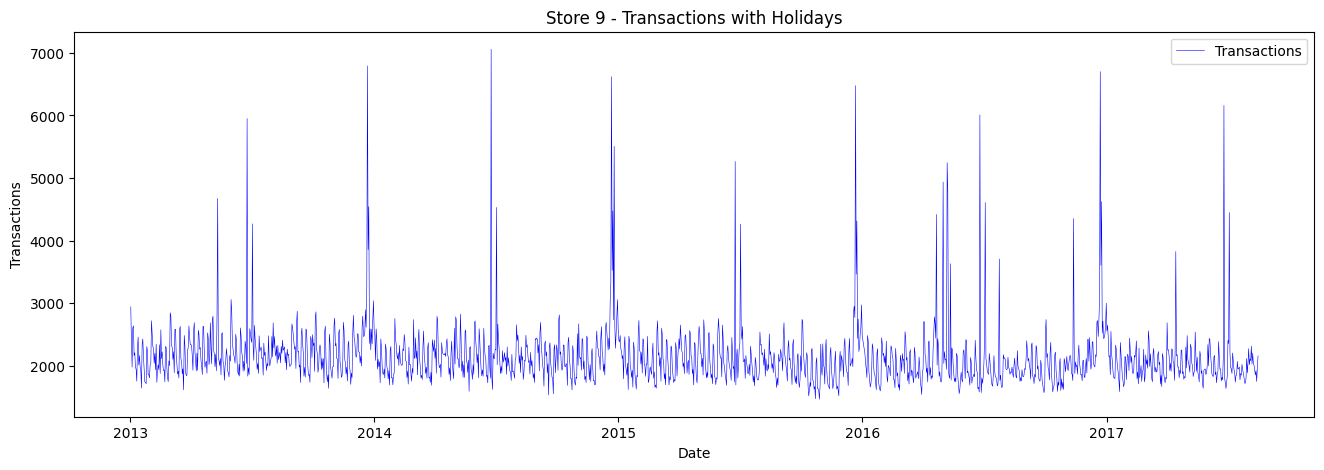

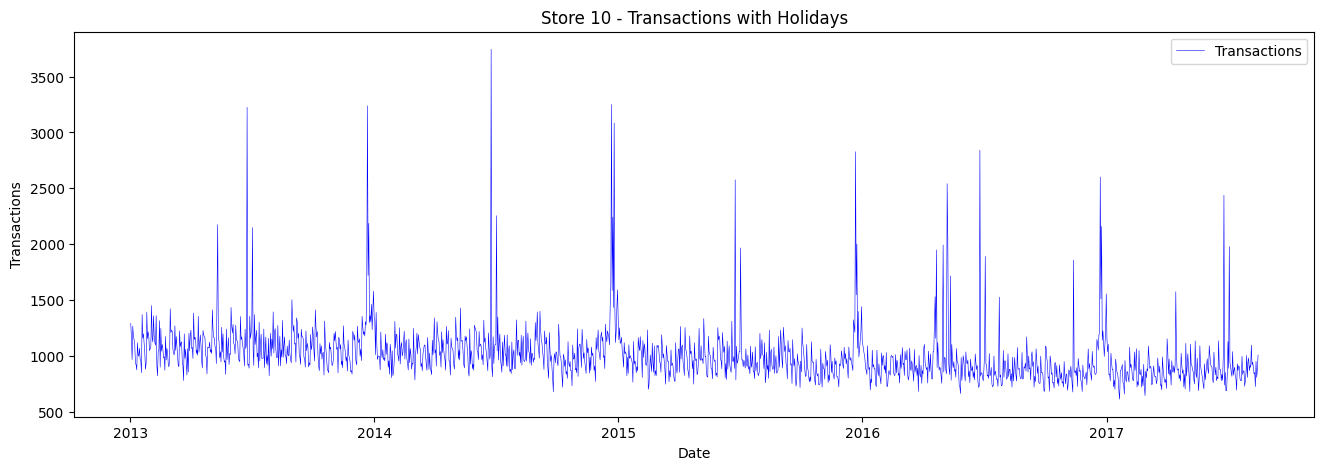

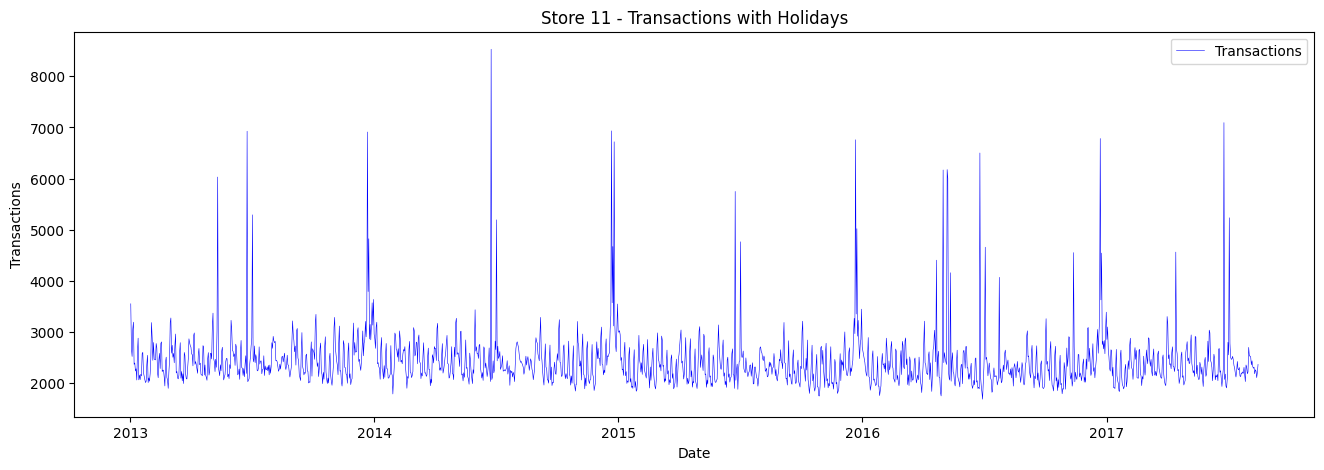

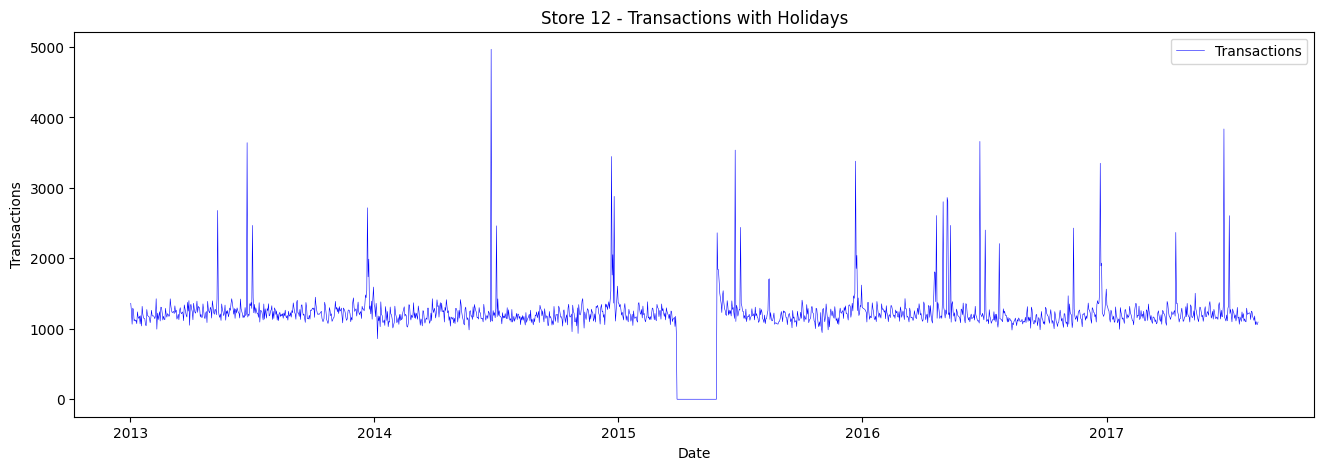

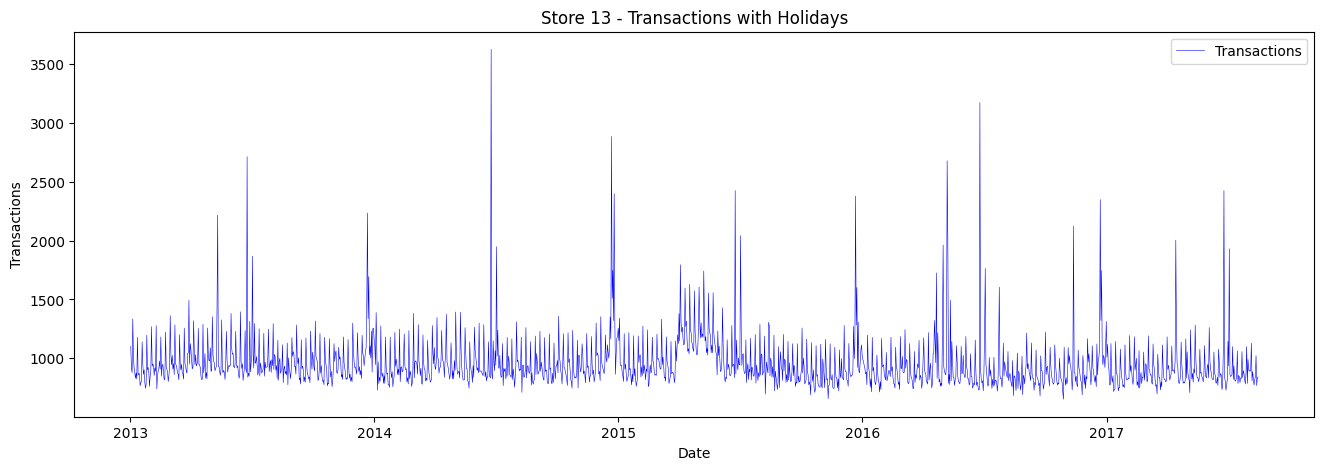

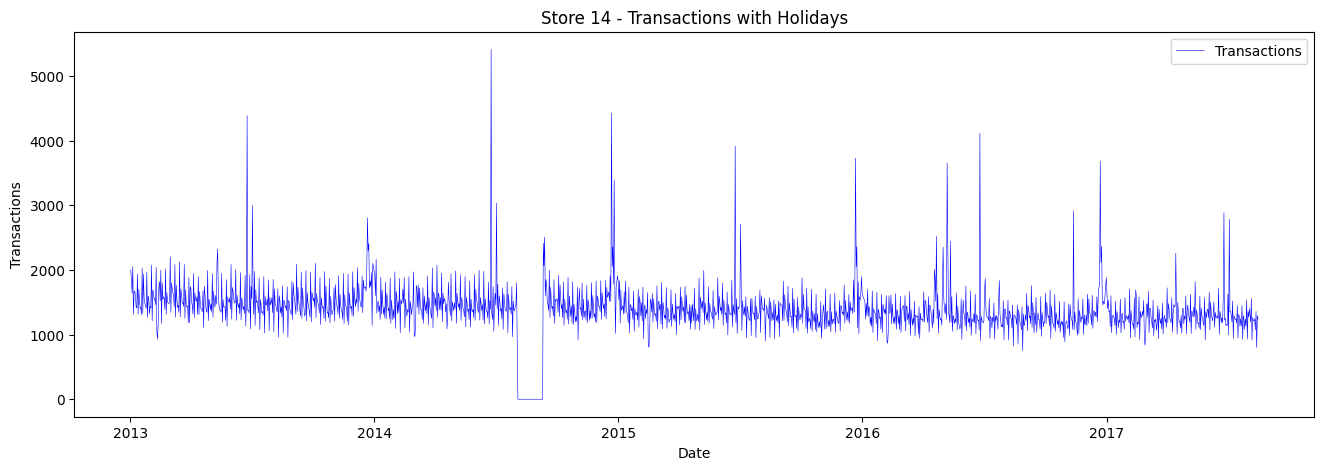

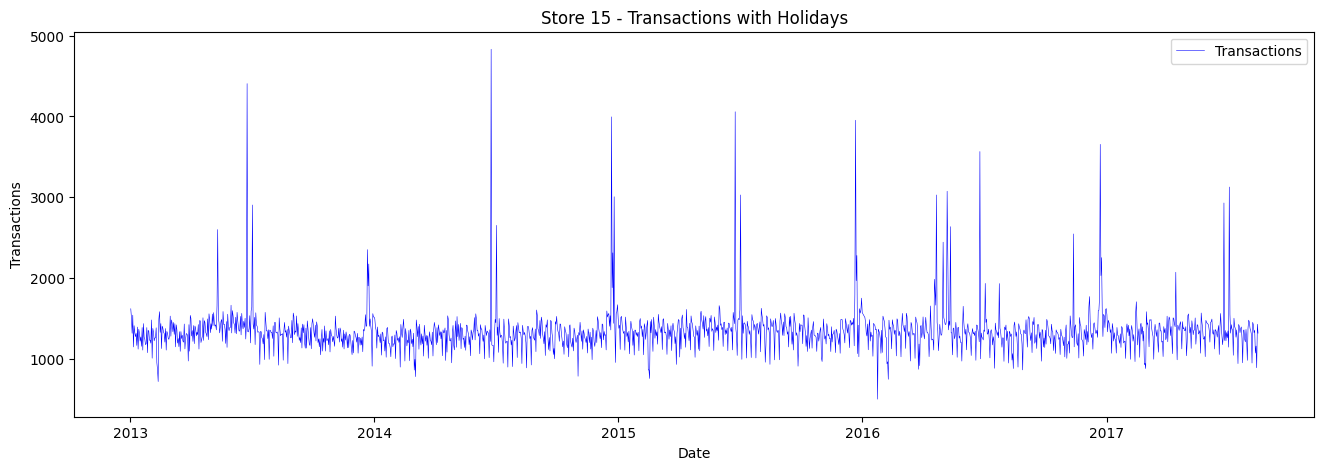

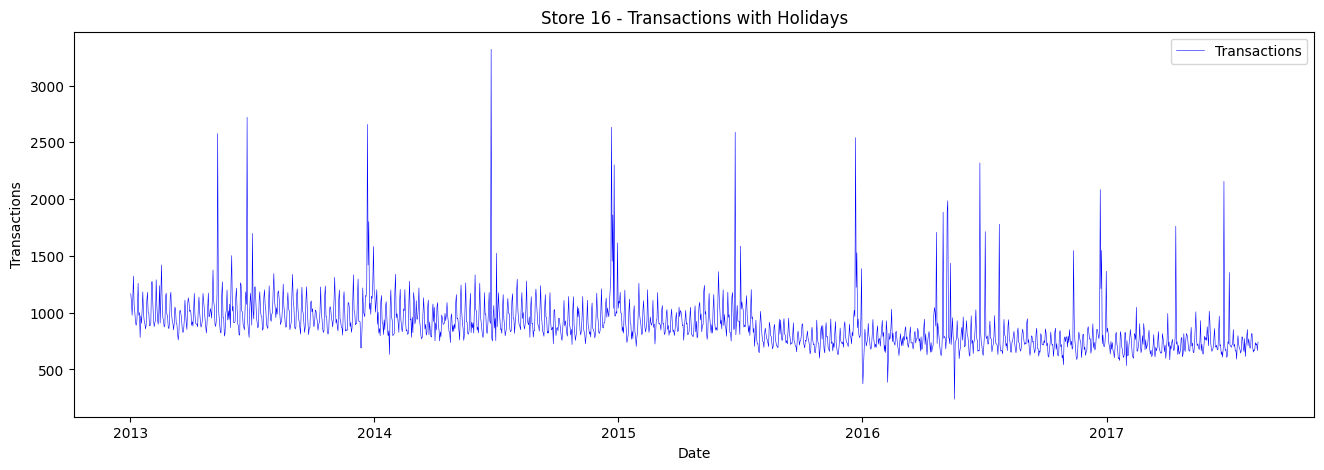

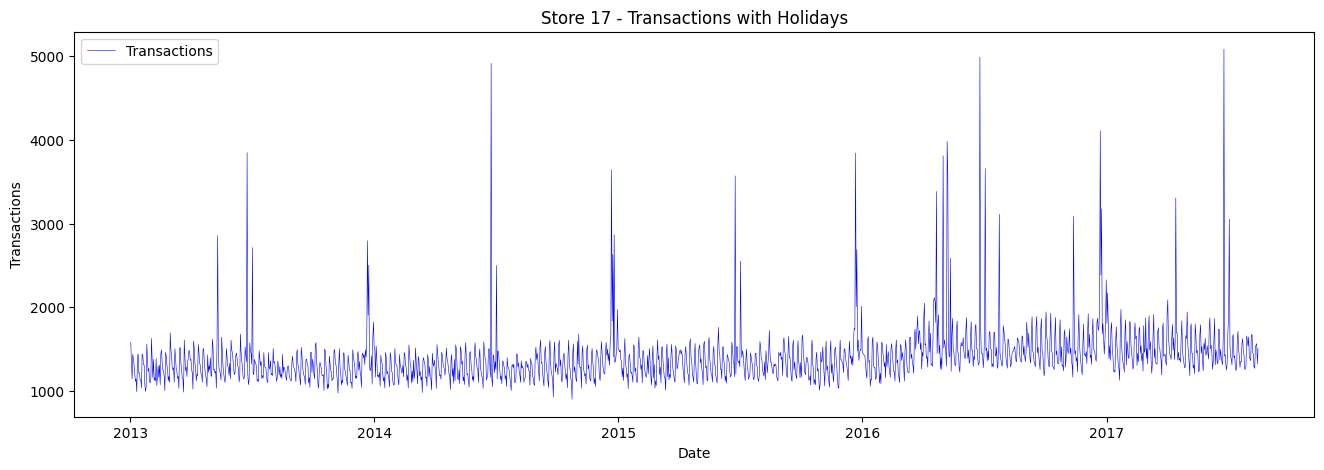

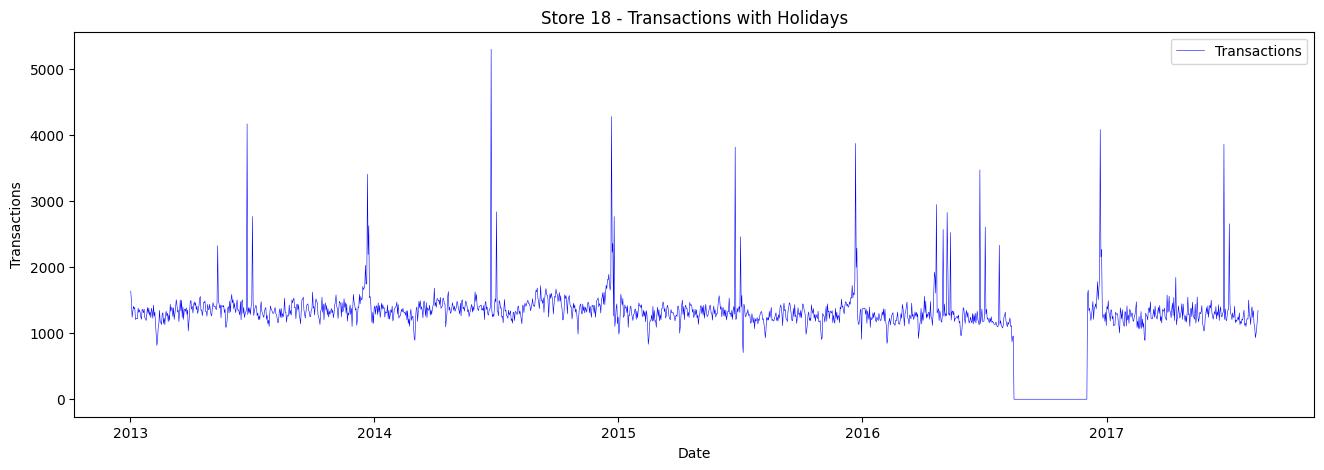

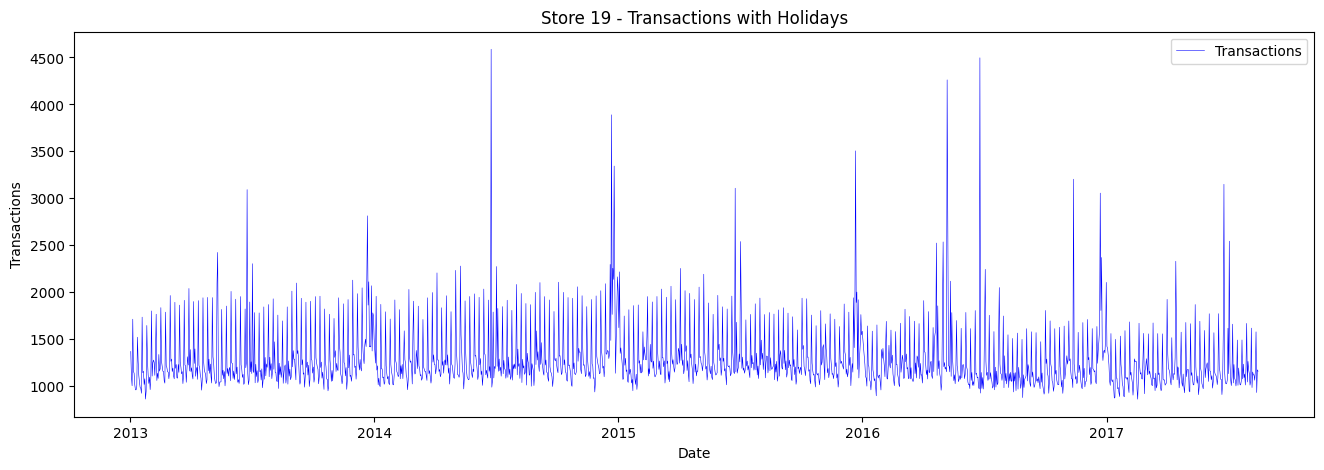

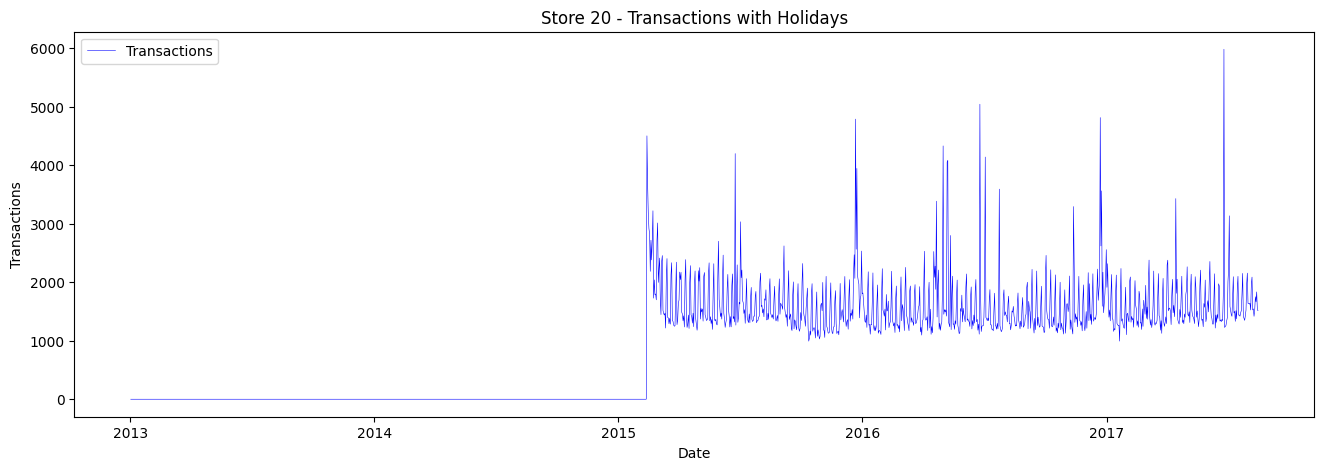

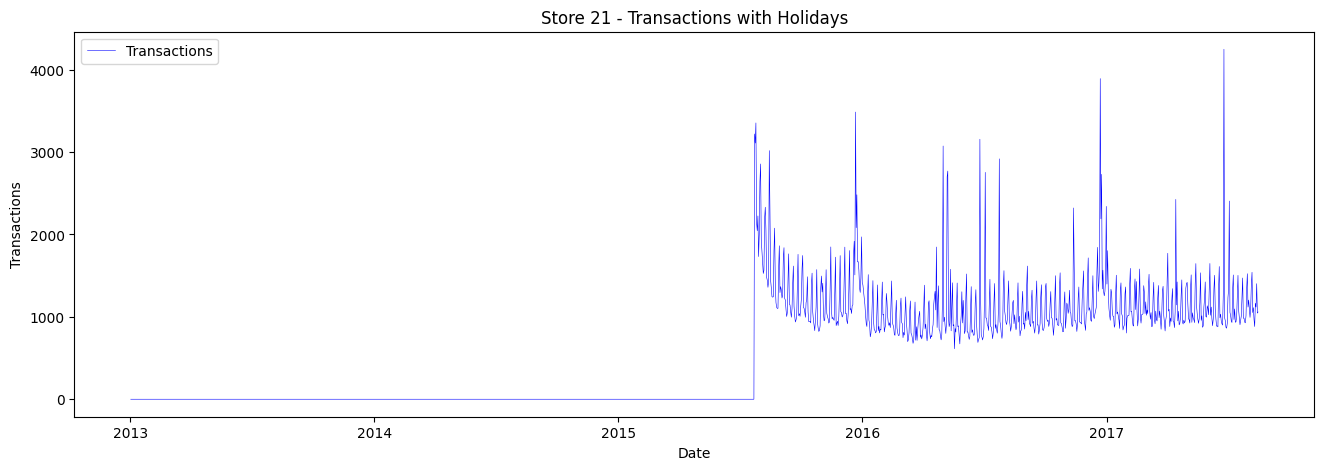

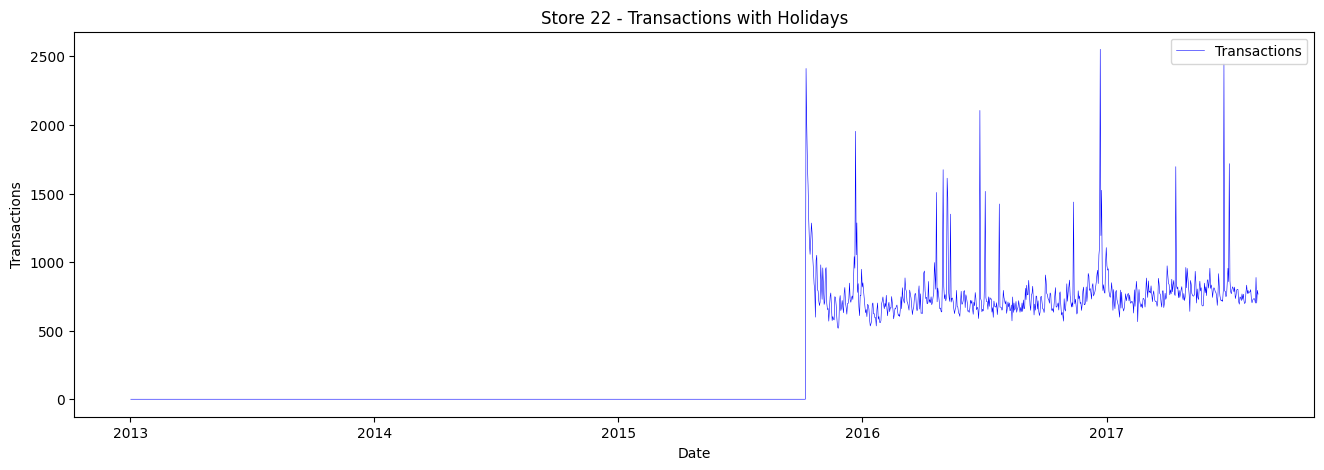

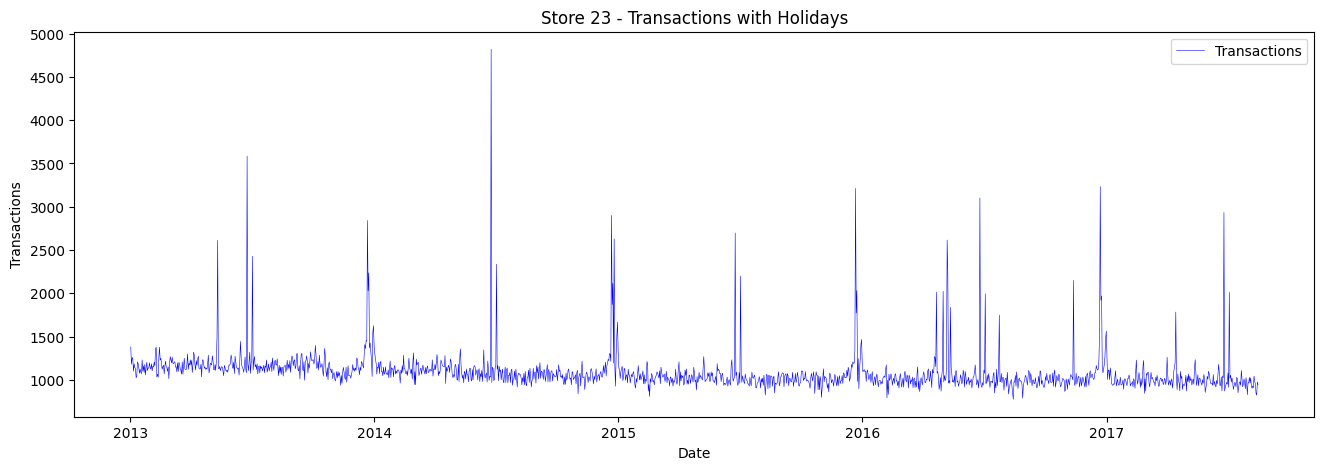

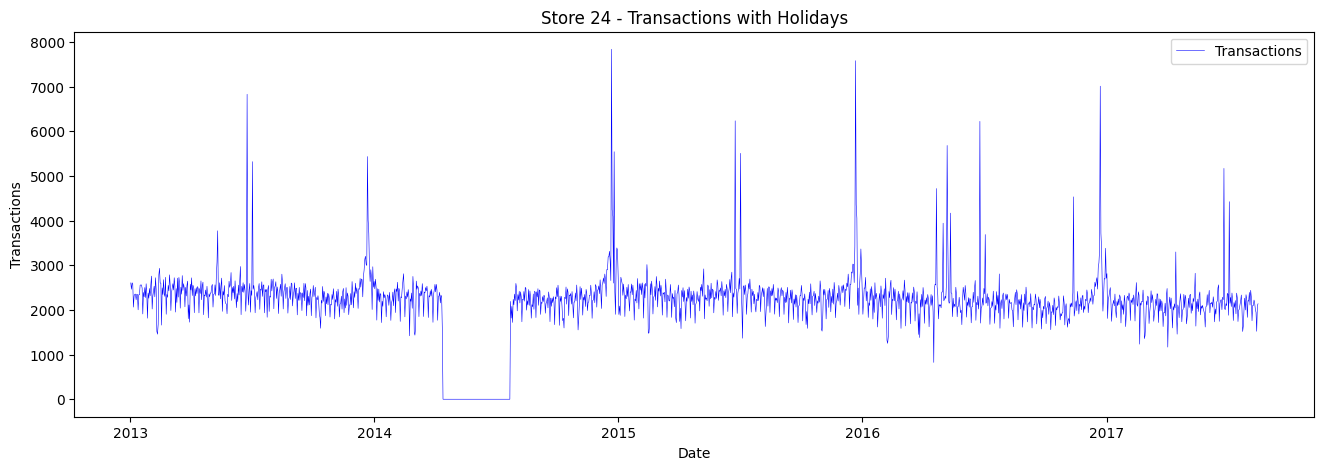

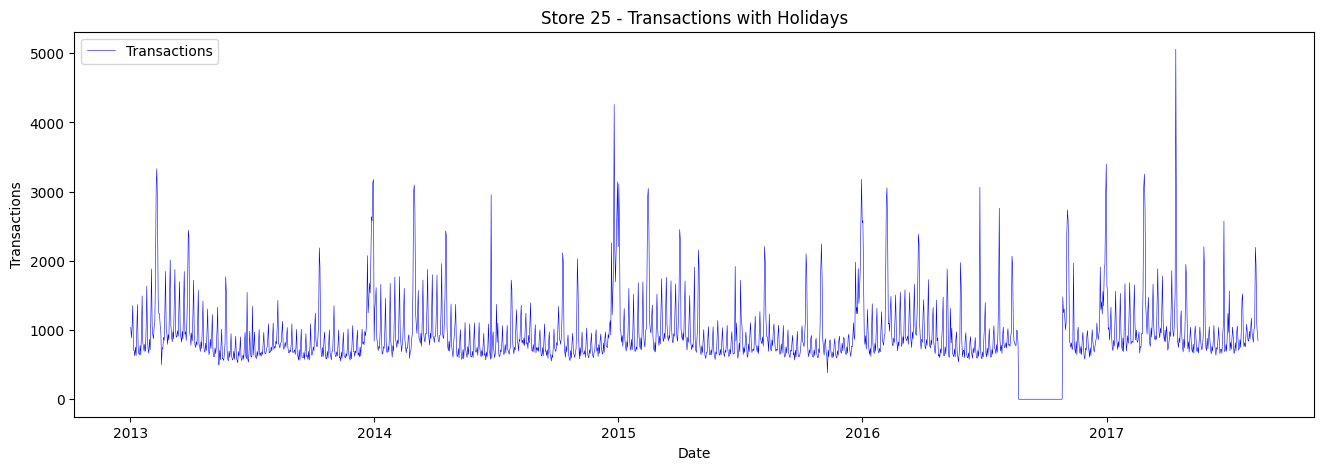

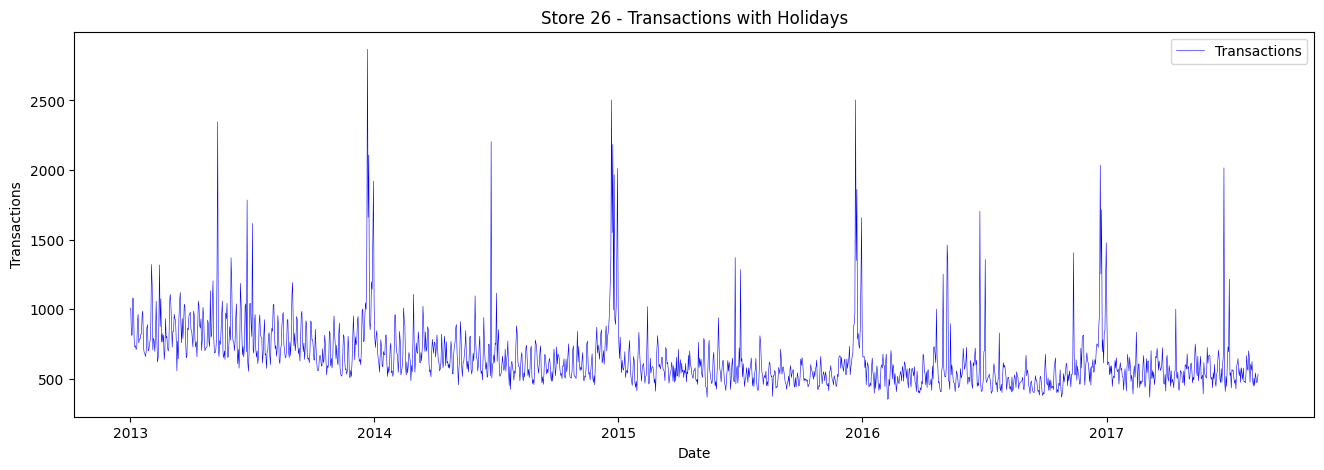

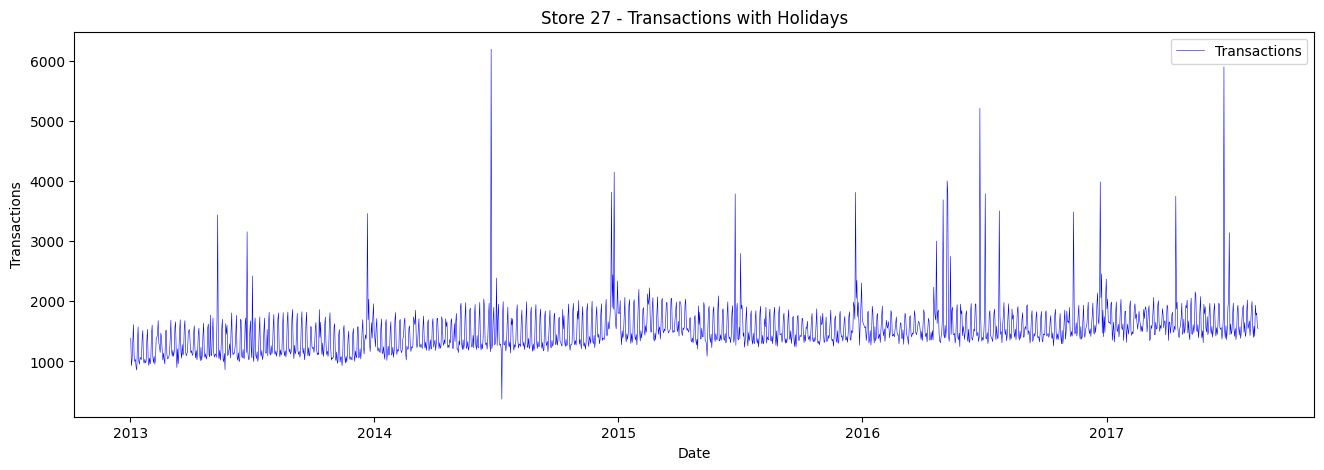

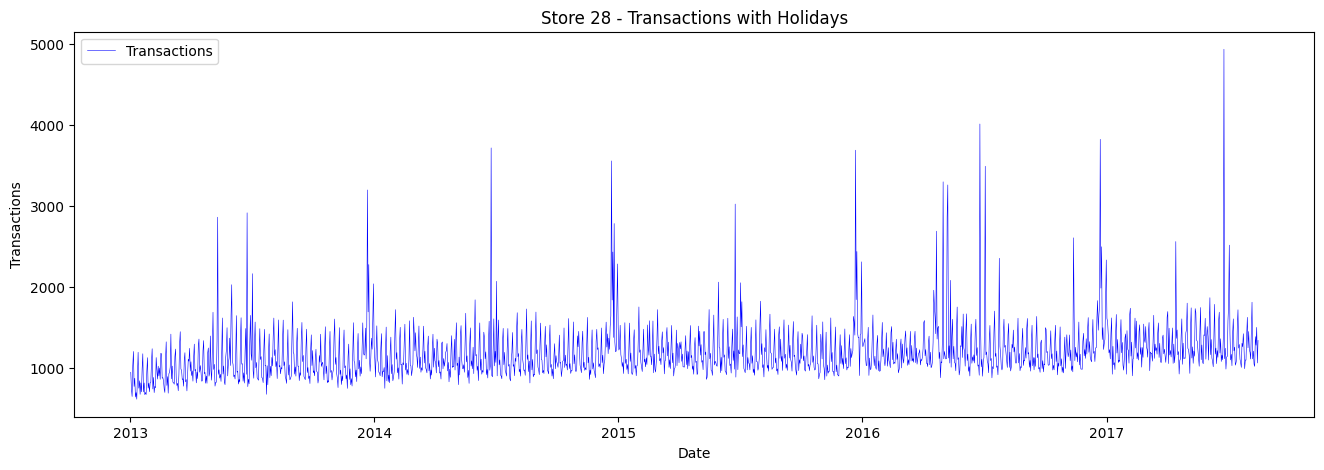

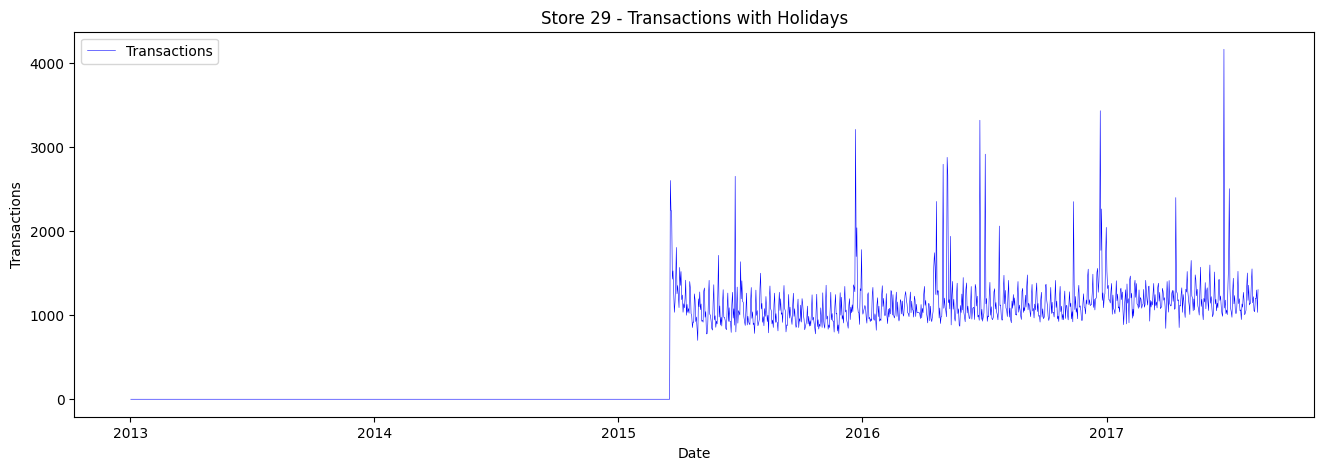

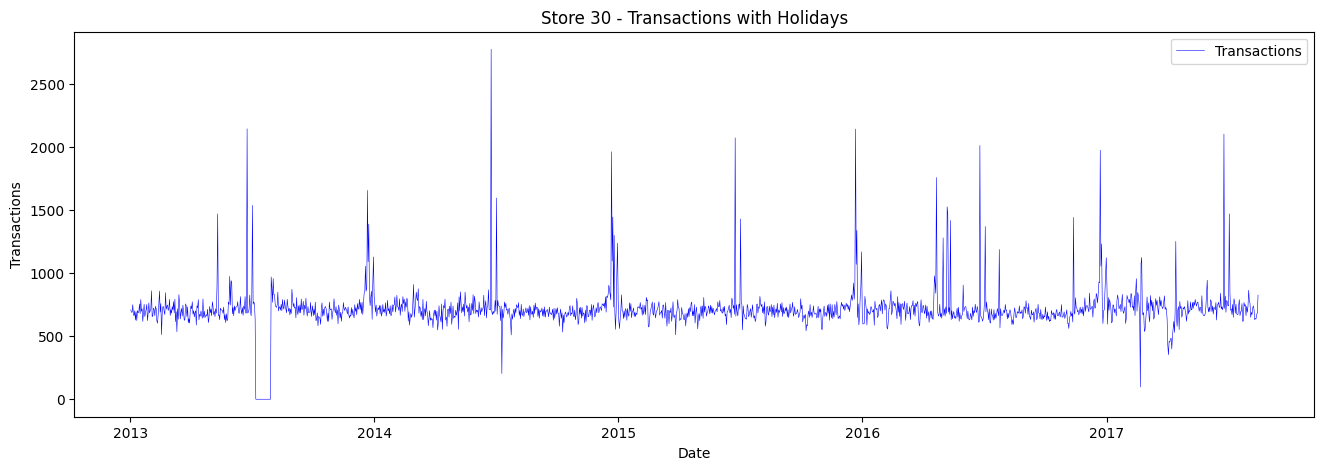

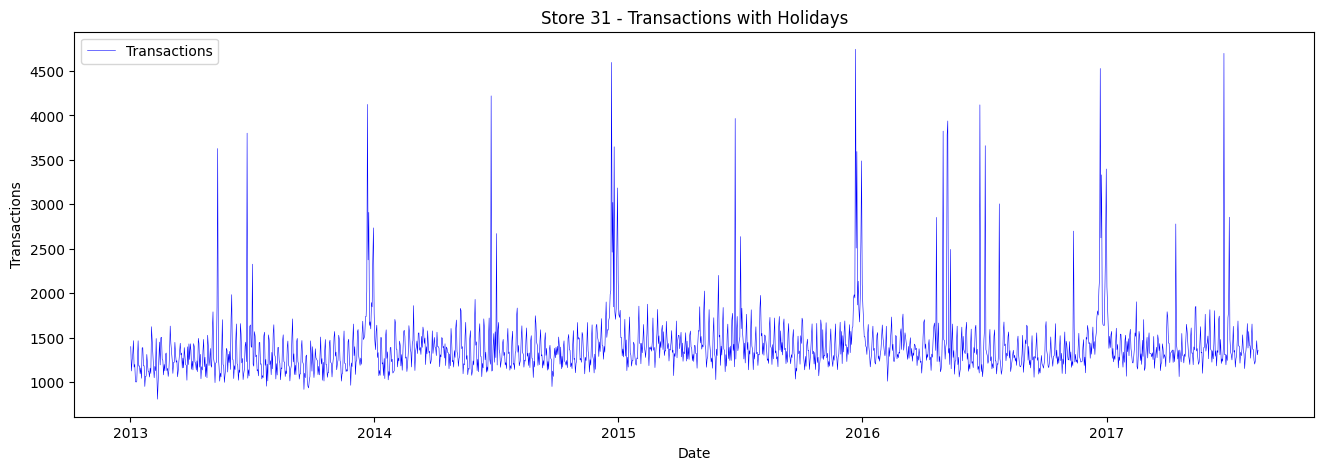

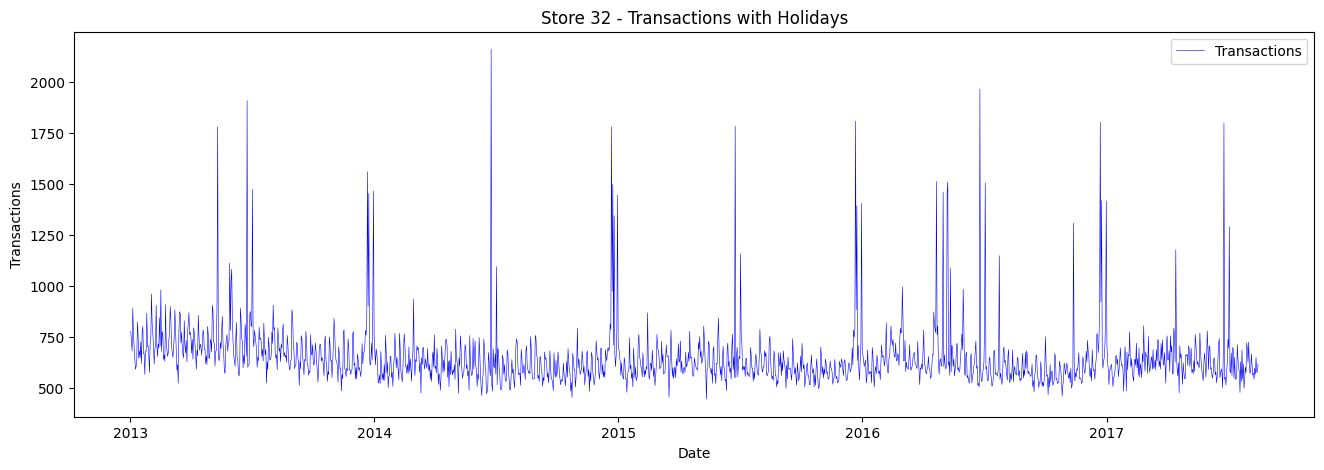

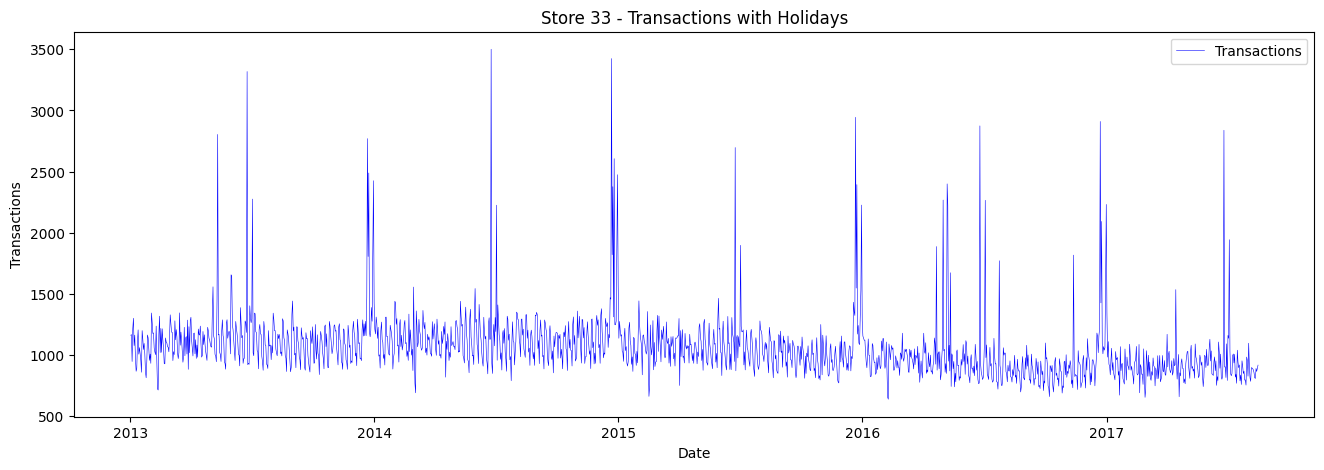

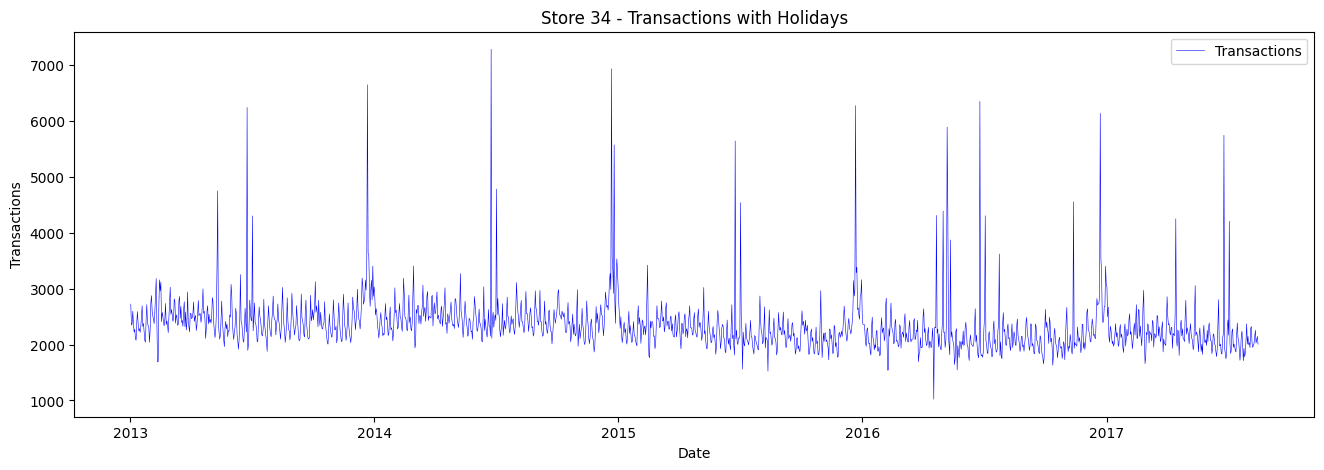

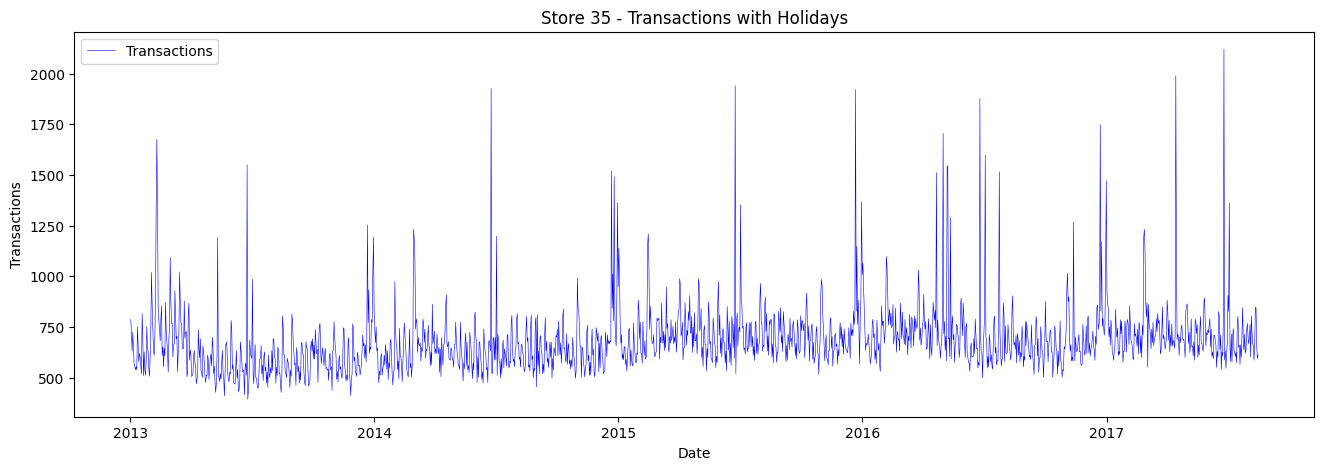

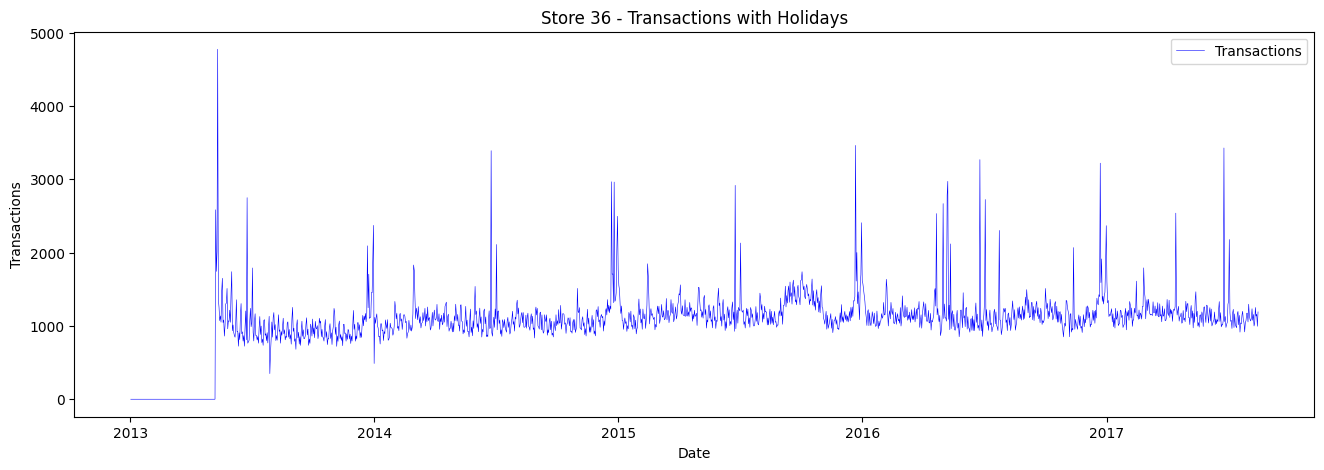

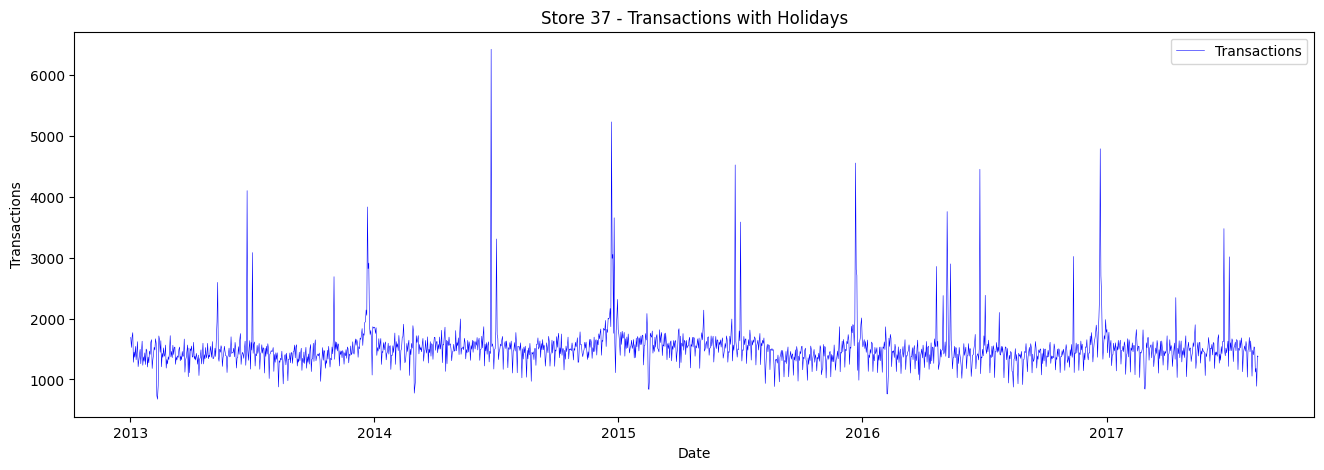

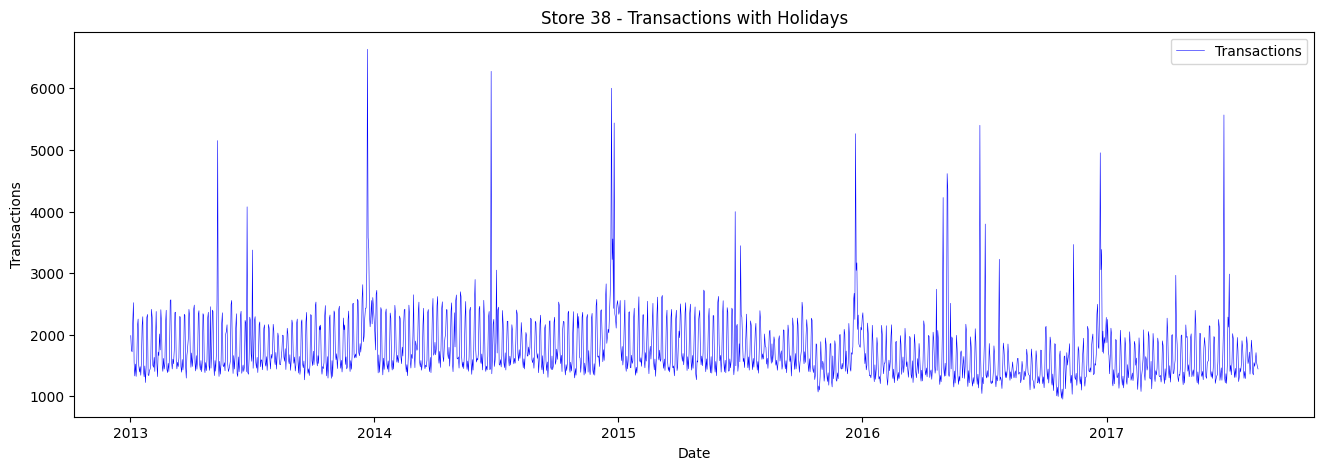

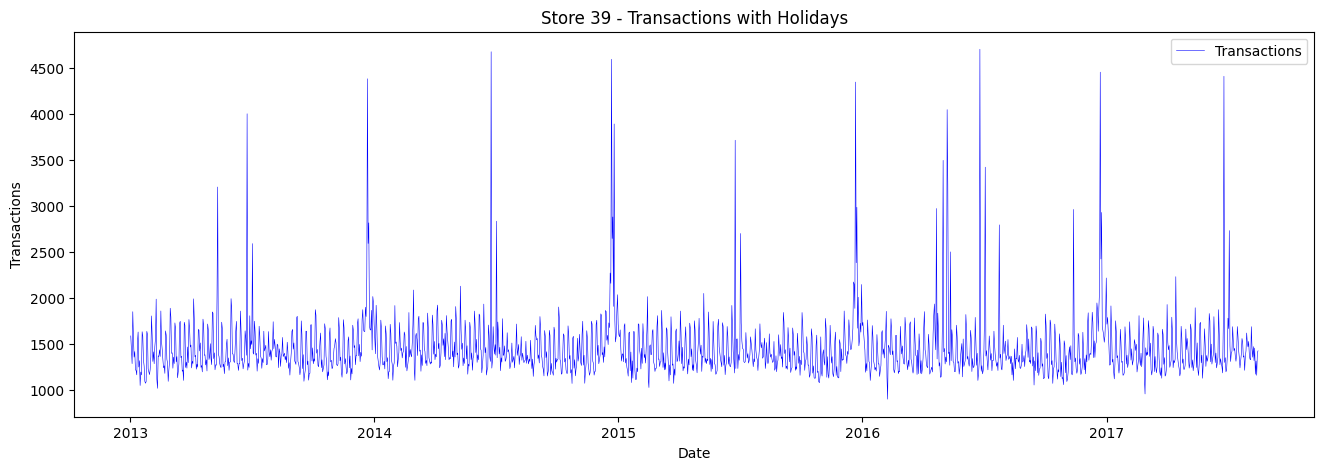

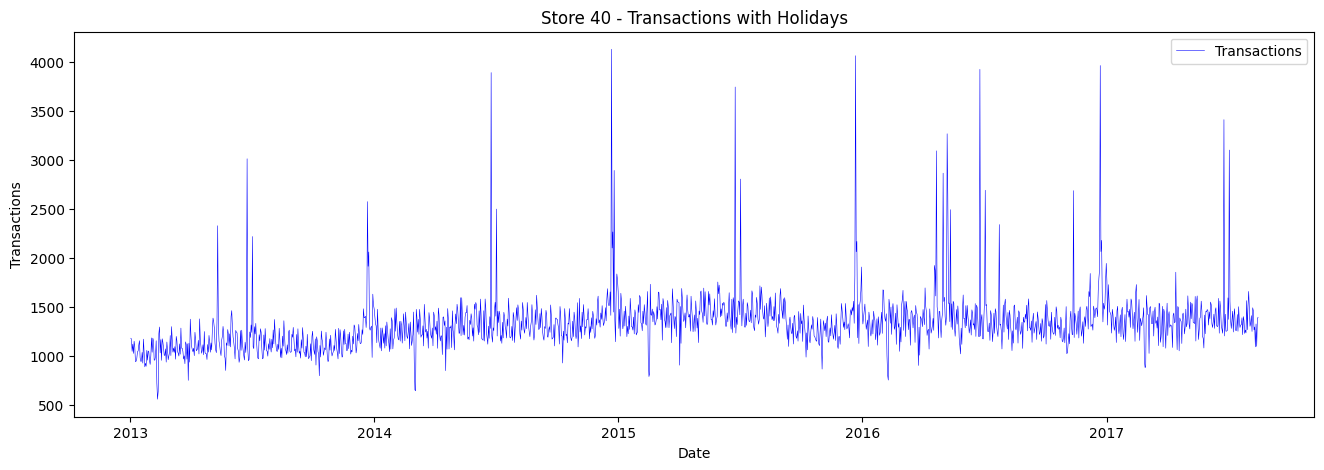

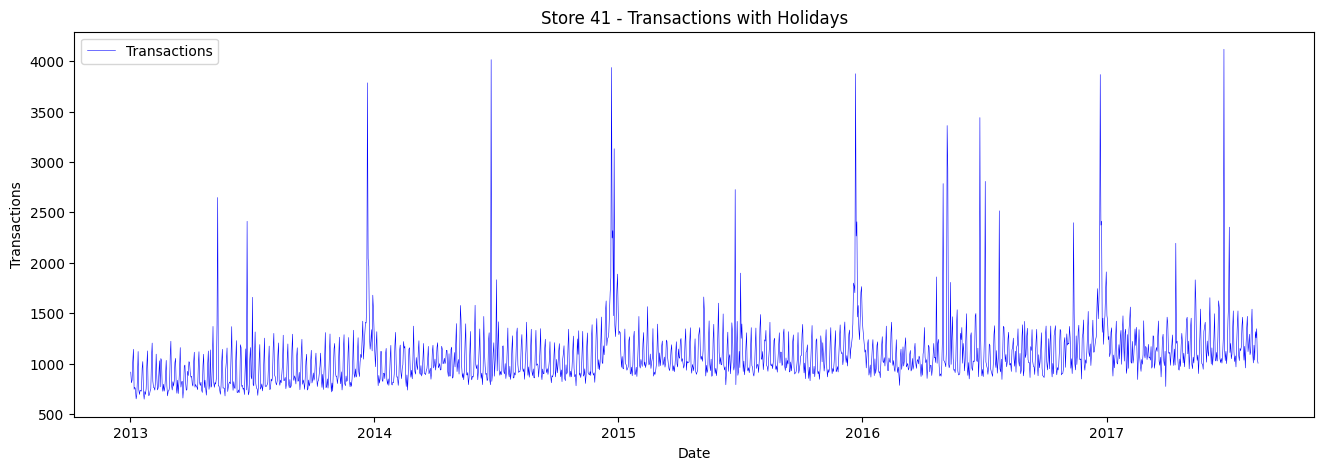

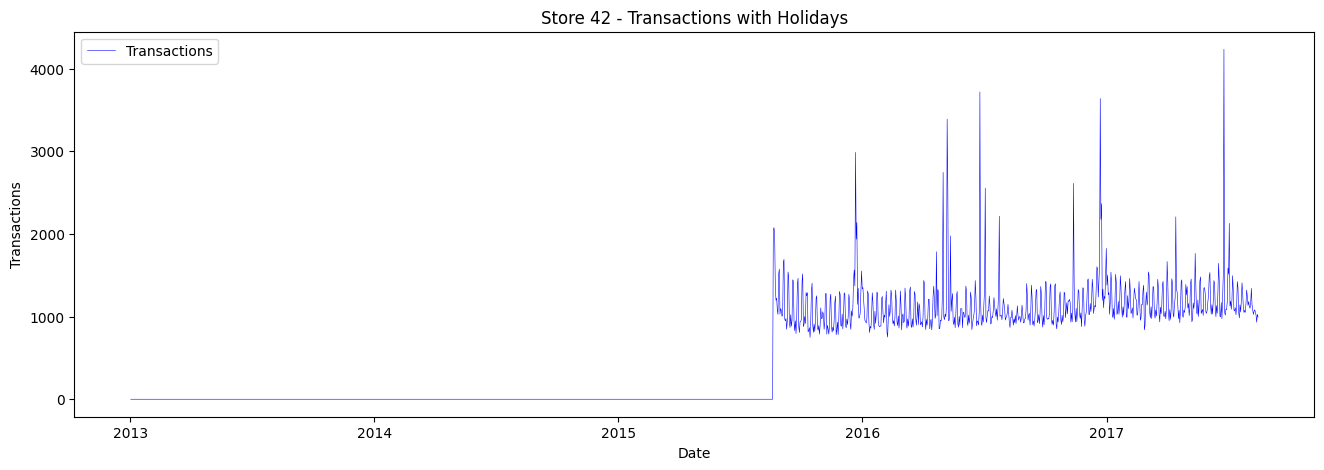

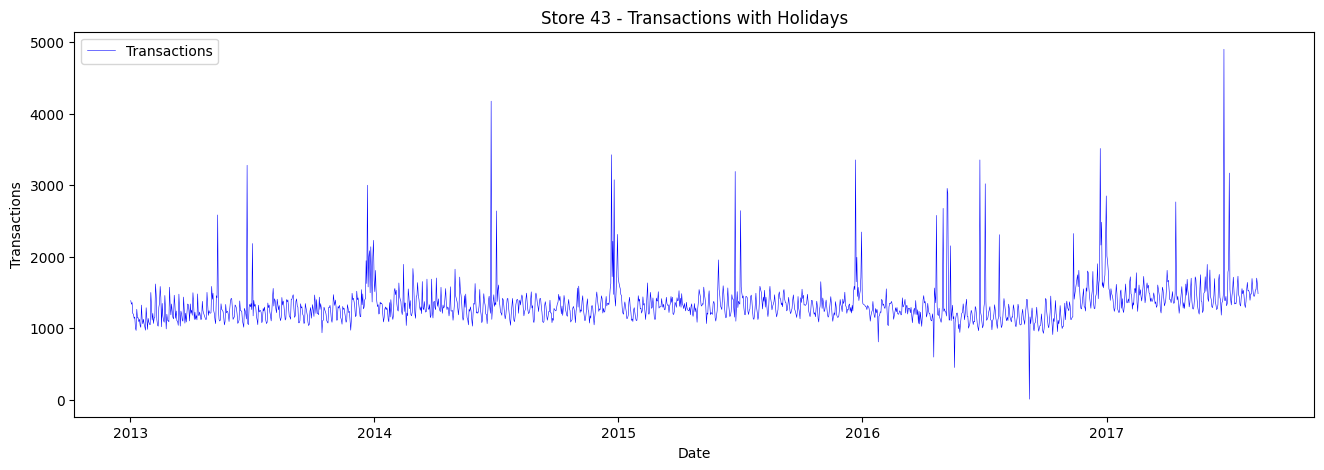

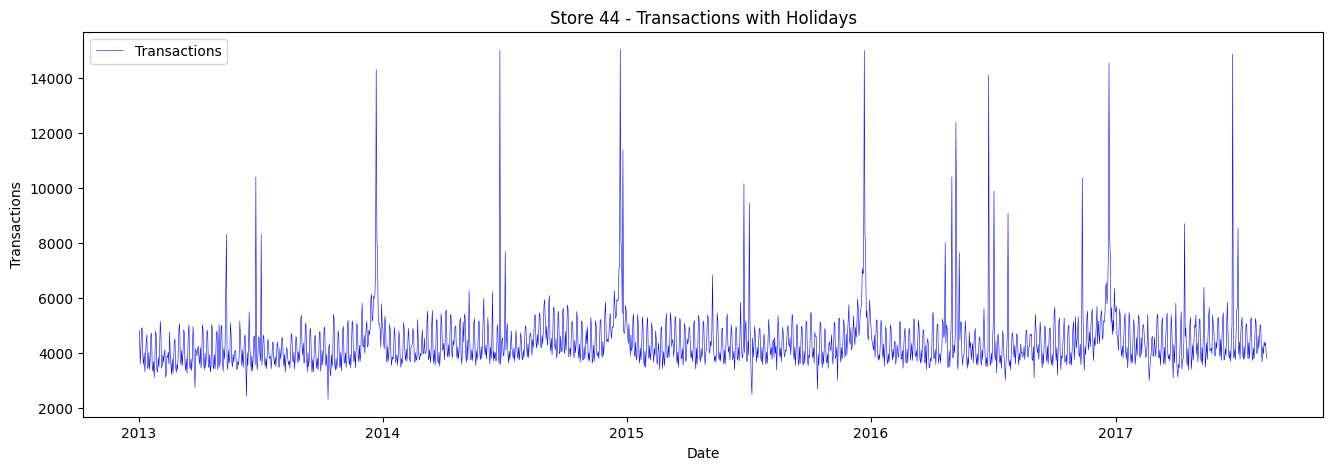

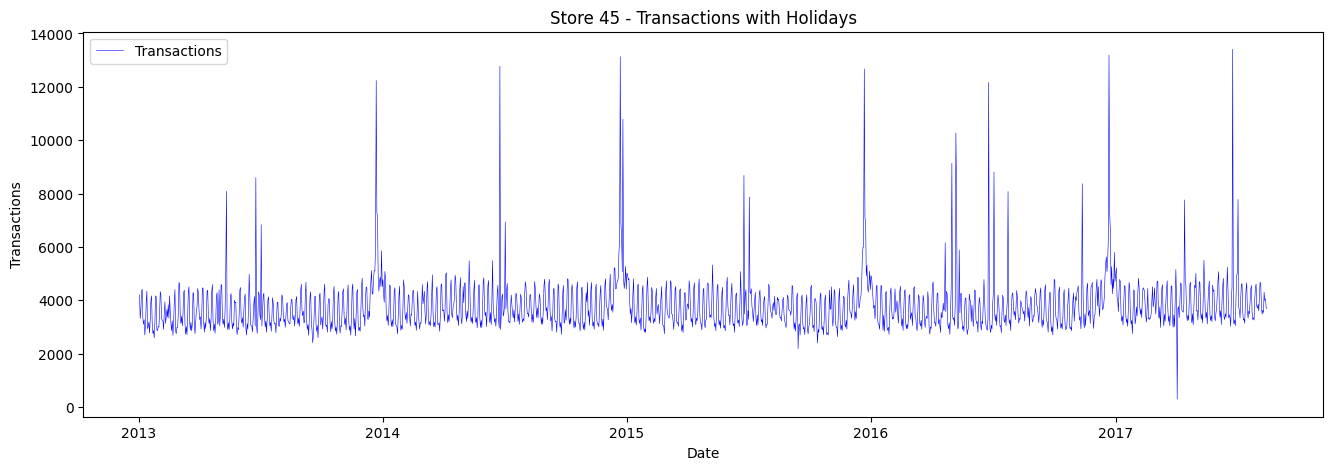

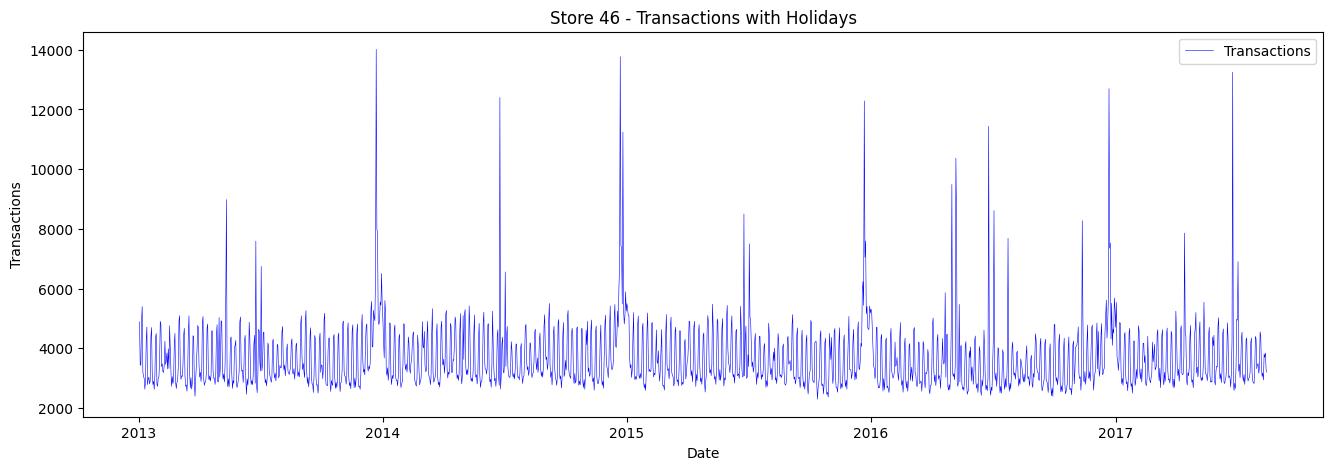

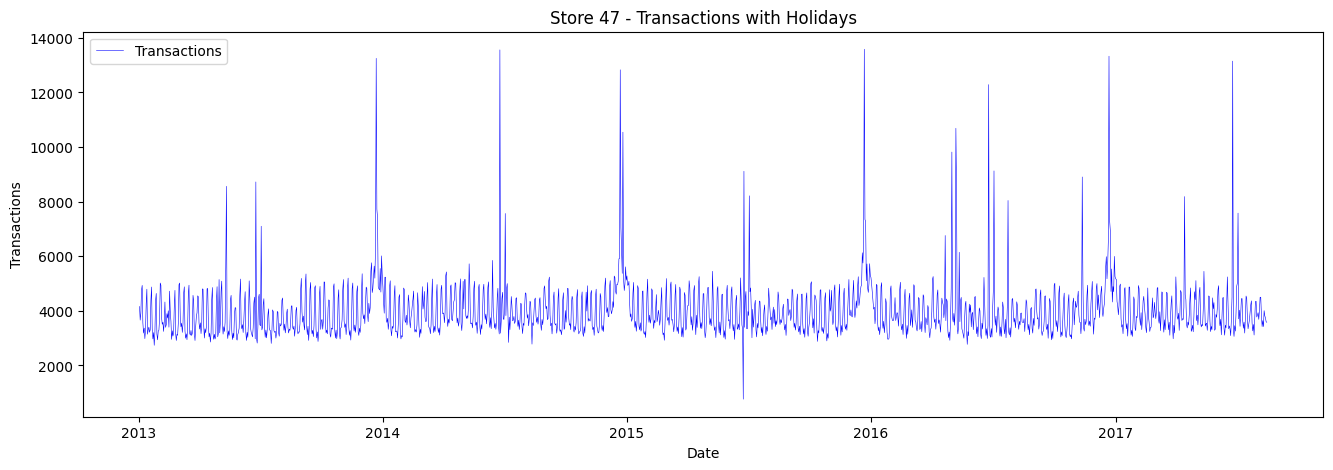

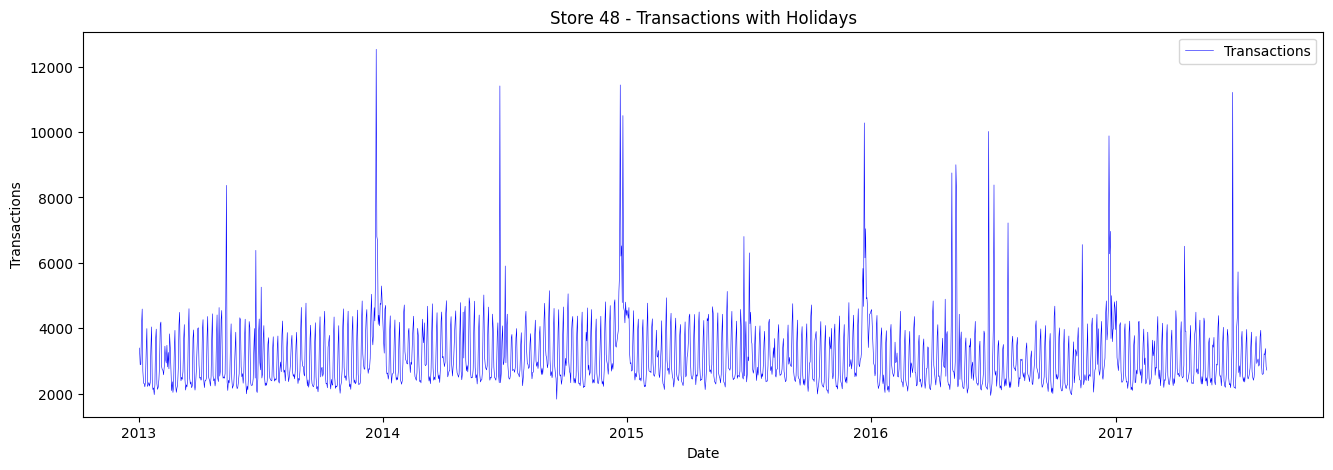

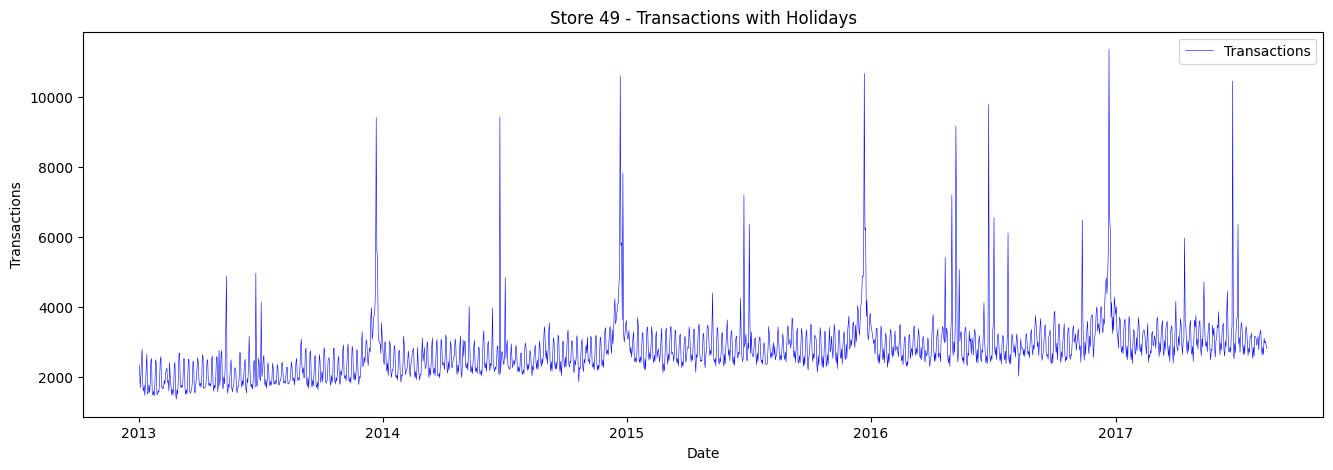

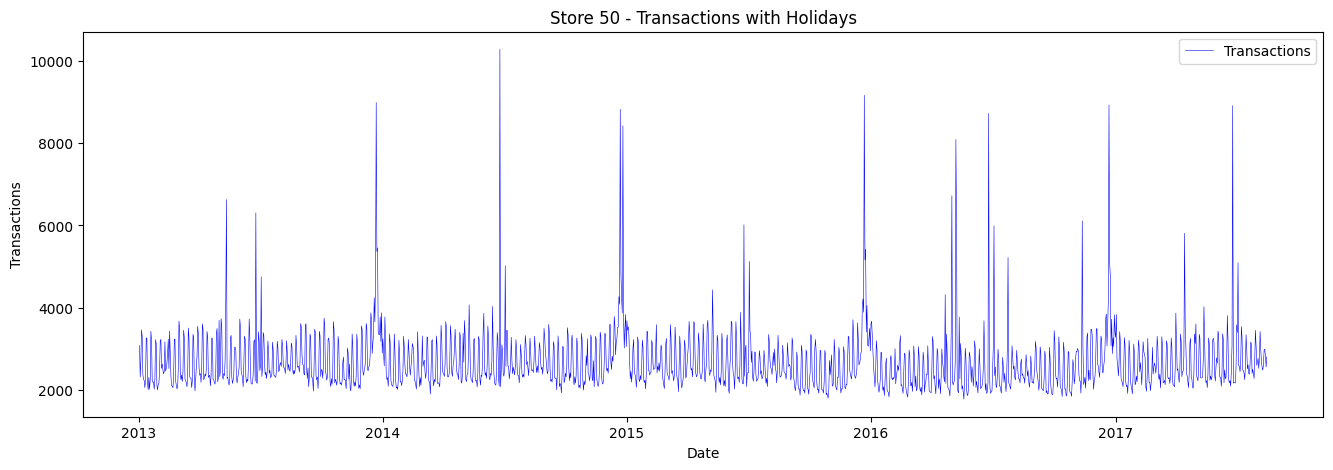

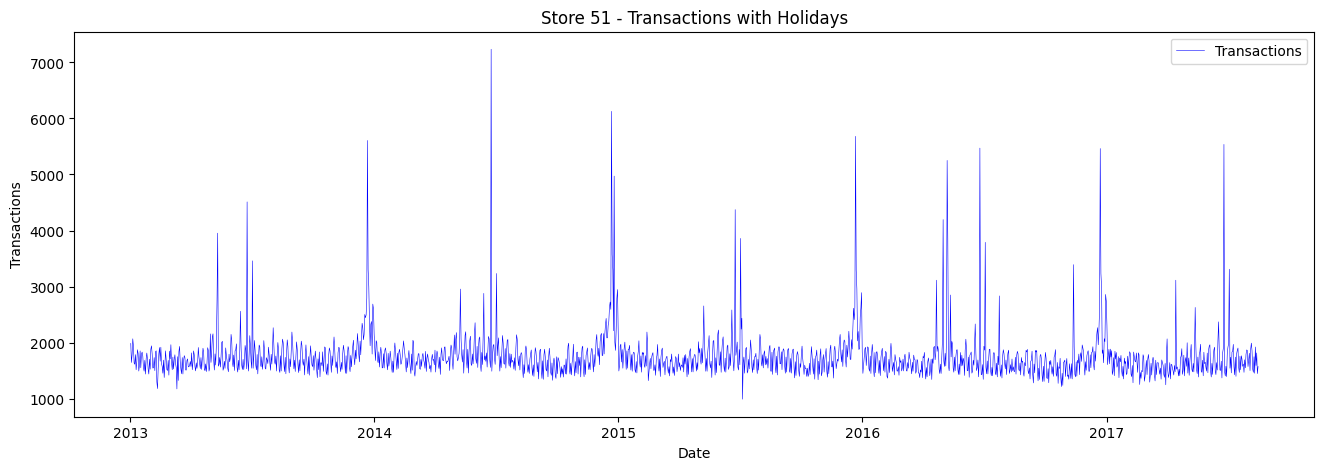

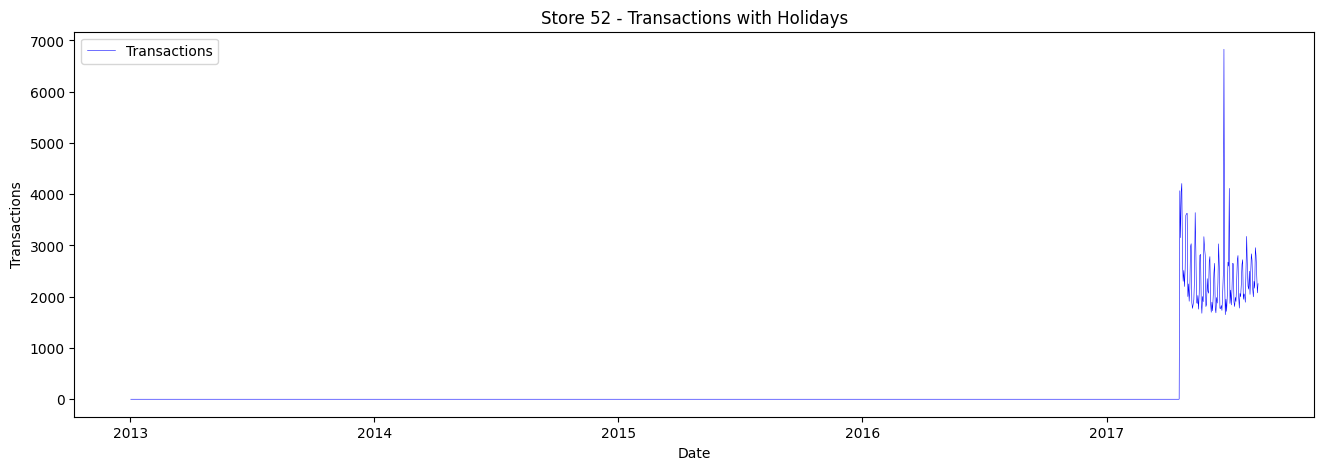

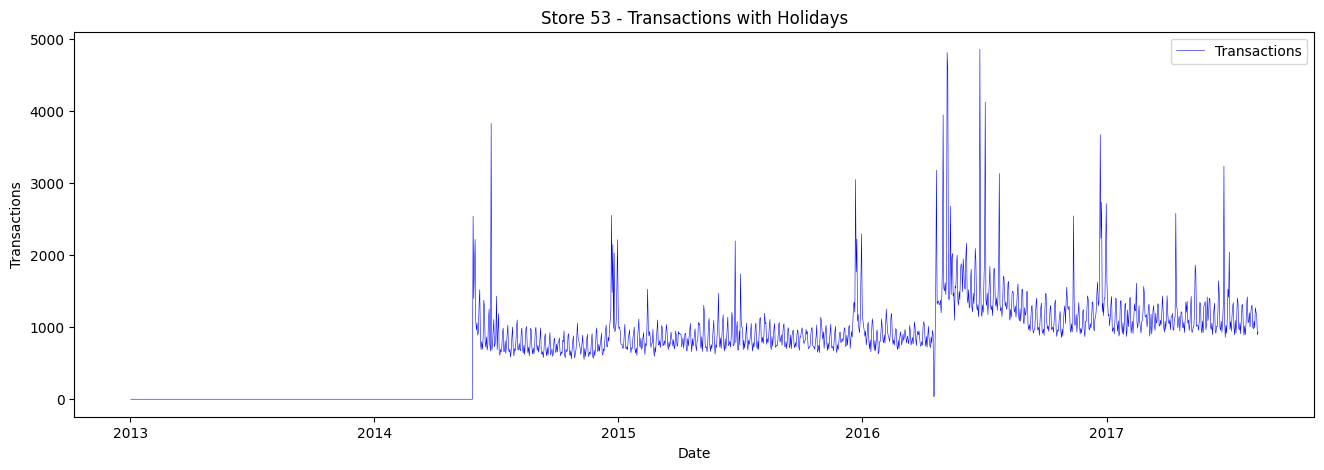

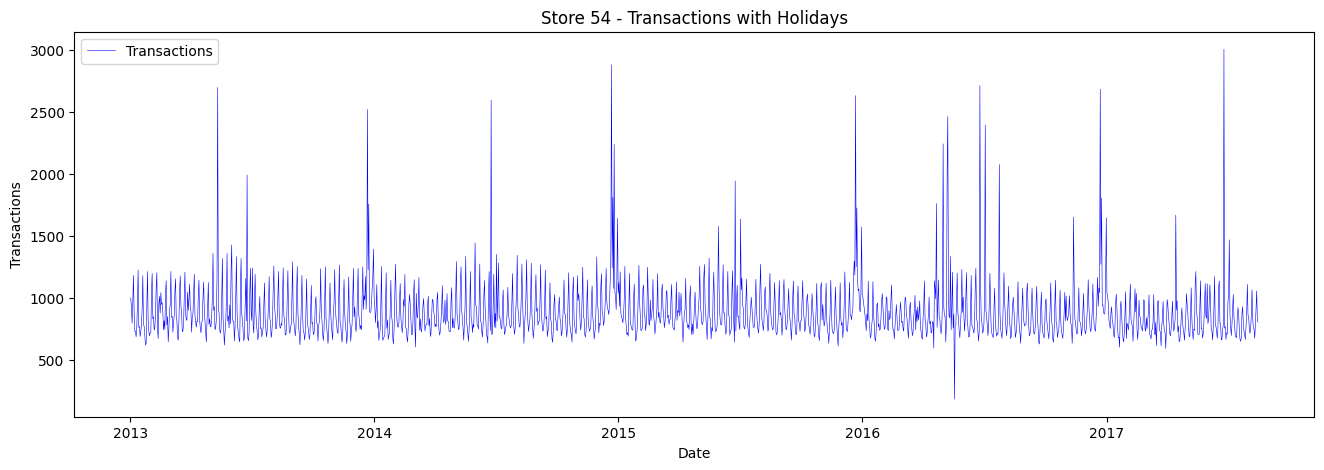

In [27]:
# ===================================================
#                   VISUALIZATION
# ===================================================
stores_unique = df_full['store_nbr'].unique()

for store in stores_unique:
    store_df = df_full[df_full['store_nbr'] == store].sort_values('date')

    fig, ax = plt.subplots(figsize=(16,5))
    ax.plot(store_df['date'], store_df['transaction'], label="Transactions", color="blue", linewidth=0.4, alpha=1)



    """holiday_dates = store_df.loc[store_df['is_holiday'] == 1, 'date']
    for hday in holiday_dates:
        ax.axvline(hday, color="orange", linestyle="--", linewidth=0.5)
    """
    """
    closed_dates = store_df.loc[store_df['store_open'] == 0, 'date']
    for cdate in closed_dates:
        ax.axvline(cdate, color="orange", linestyle="-", linewidth=0.5)
    """
    open_but_no_data = store_df.loc[
        (store_df['store_open'] == 1) &
        (store_df['is_holiday'] == 0) &
        (store_df['transaction'].isna()),
        'date'
    ]
    for obnd in open_but_no_data:
        ax.axvline(obnd, color="red", linestyle="-", linewidth=0.5)

    ax.set_title(f"Store {store} - Transactions with Holidays")
    ax.set_xlabel("Date")
    ax.set_ylabel("Transactions")
    ax.legend()

    plt.show()

# 3 Handling Outliers
    a. Detect outliers using methods such as the IQR method or Z-score.
    b. Decide whether to remove, cap, or transform the outliers. Justify your decisions.

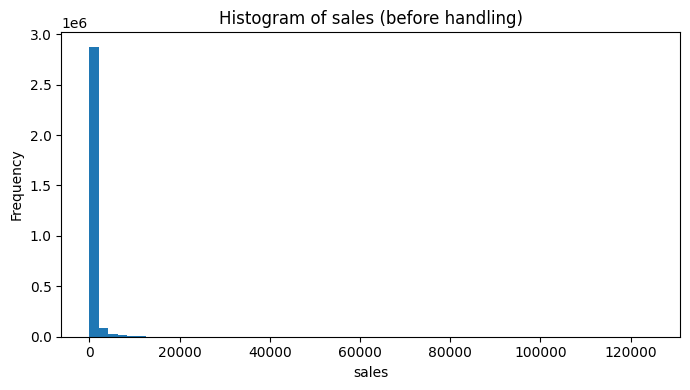

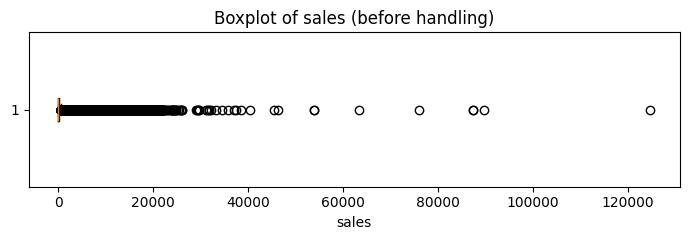

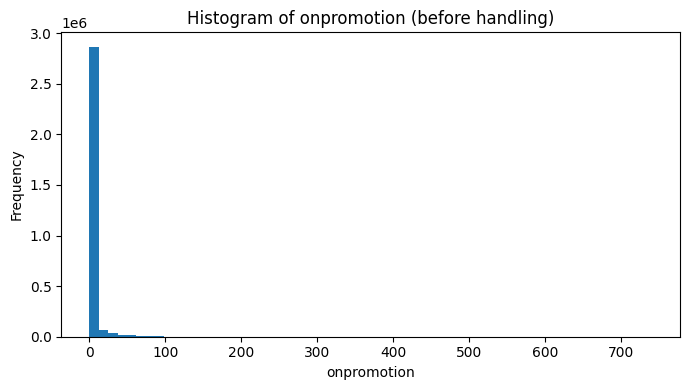

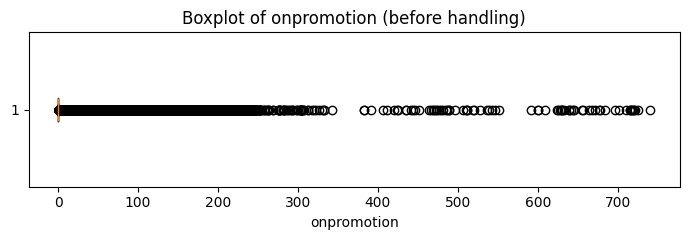

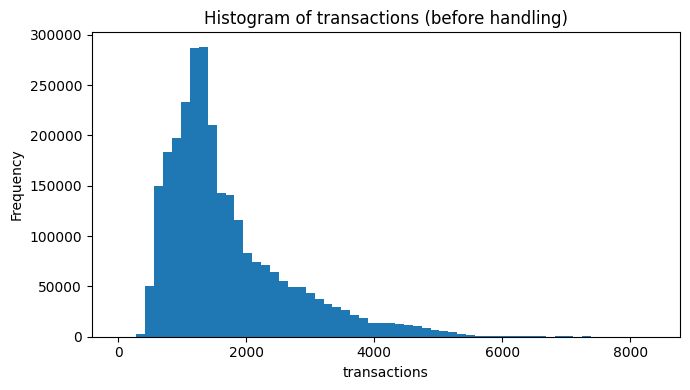

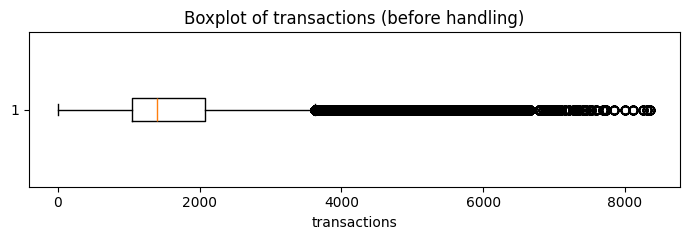

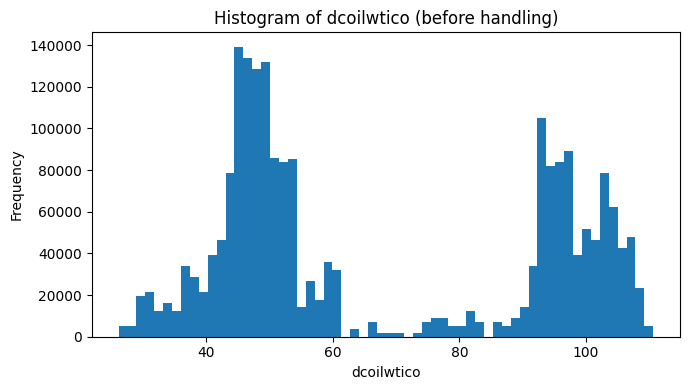

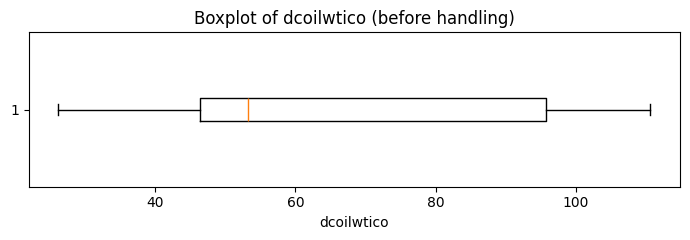


=== Outlier counts (IQR) ===
sales          : 449468
onpromotion    : 615584
transactions   : 151998
dcoilwtico     : 0

=== Outlier counts (Z-Score |z|>3) ===
sales          : 65287
onpromotion    : 55256
transactions   : 47289
dcoilwtico     : 0



=== Caps used ===
onpromotion 99.5% cap:           76.0
transactions non-holiday 99.5%:  5074.0
transactions holiday  99.9%:     7727.0
oil winsor [1%, 99%]:            (29.59, 107.98)


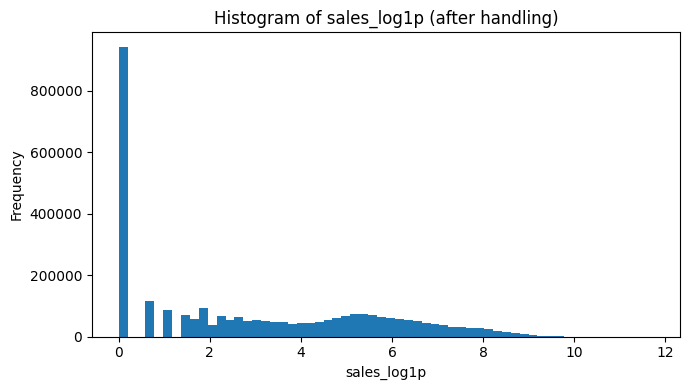

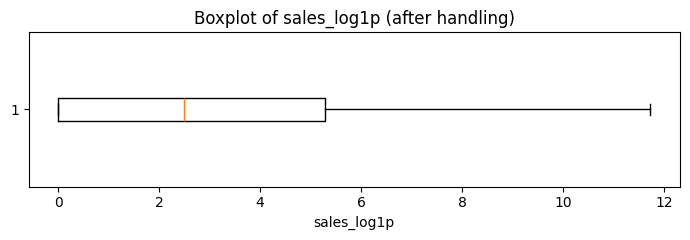

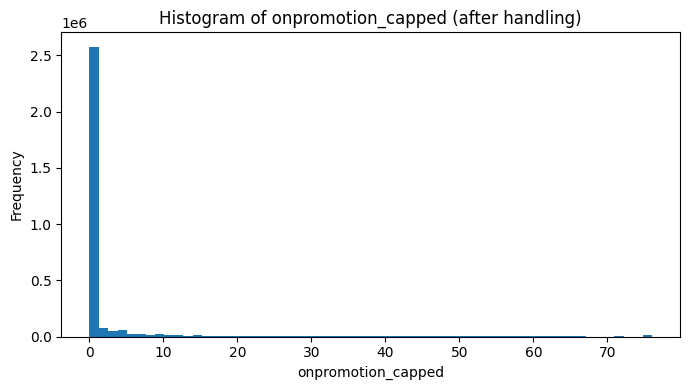

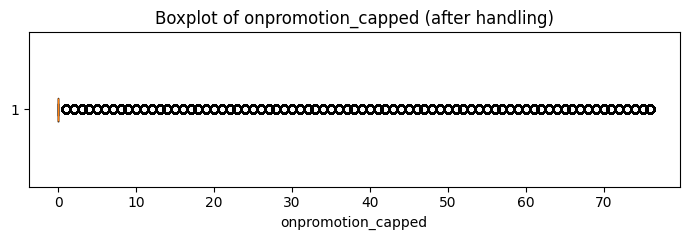

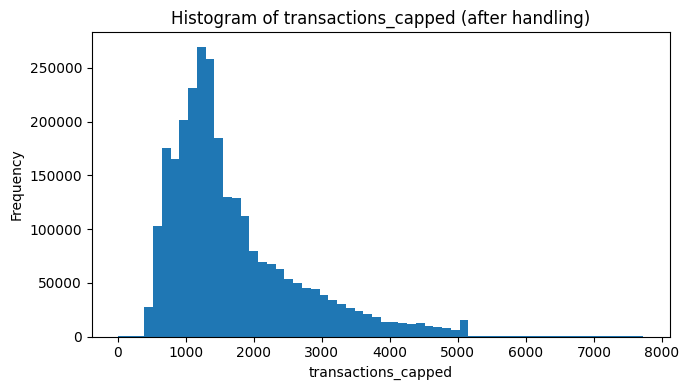

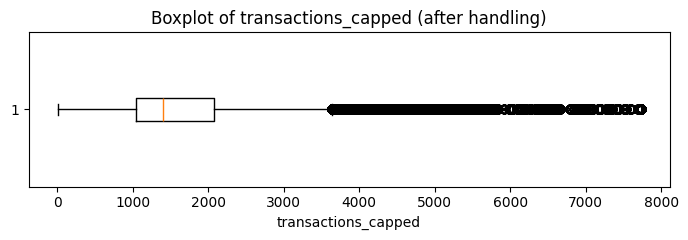

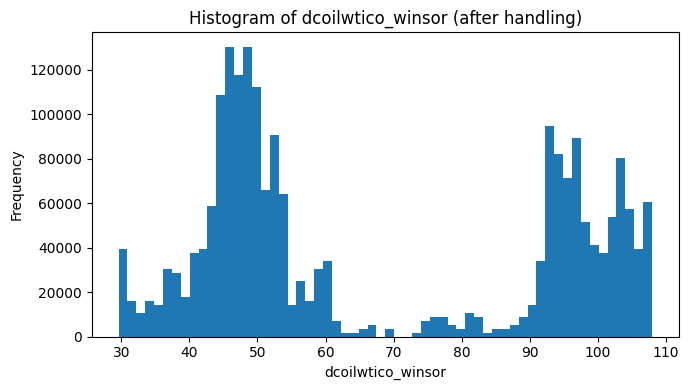

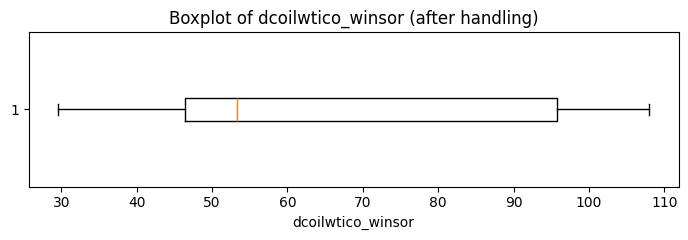


Saved cleaned dataset -> data/train_outlier_handled_with_holiday.csv


In [28]:

TRAIN_PATH   = "data/train.csv"
TX_PATH      = "data/transactions.csv"
OIL_PATH     = "data/oil.csv"
HOL_PATH     = "data/holidays_events.csv"
STORES_PATH  = "data/stores.csv"
OUT_CSV      = "data/train_outlier_handled_with_holiday.csv"
SHOW_PLOTS   = True

# ---------------------------
# 1) Load data
# ---------------------------
train        = pd.read_csv(TRAIN_PATH, parse_dates=["date"])
transactions = pd.read_csv(TX_PATH,    parse_dates=["date"])
oil          = pd.read_csv(OIL_PATH,   parse_dates=["date"])
holidays     = pd.read_csv(HOL_PATH,   parse_dates=["date"])
stores       = pd.read_csv(STORES_PATH)

# Normalize timestamps (remove time component if present)
for df_ in (train, transactions, oil, holidays):
    df_["date"] = pd.to_datetime(df_["date"]).dt.normalize()

# Ensure IDs are integers
train["store_nbr"]        = train["store_nbr"].astype(int)
transactions["store_nbr"] = transactions["store_nbr"].astype(int)
stores["store_nbr"]       = stores["store_nbr"].astype(int)

# ---------------------------
# 2) Build holiday flag (date, store_nbr)
# ---------------------------
if holidays["transferred"].dtype != bool:
    holidays["transferred"] = (
        holidays["transferred"].astype(str).str.lower()
        .map({"true": True, "false": False}).fillna(False)
    )

hol = holidays.copy()

# type == "Transfer" -> actually celebrated that date -> treat as Holiday
hol.loc[hol["type"] == "Transfer", "type"] = "Holiday"
# transferred == True -> essentially a normal Work Day
hol.loc[hol["transferred"] == True, "type"] = "Work Day"

# Start from transactions coverage to define (date, store)
tx = transactions[["date", "store_nbr", "transactions"]].copy()

# Add city/state to resolve Regional/Local logic
txh = tx.merge(stores[["store_nbr", "city", "state"]], on="store_nbr", how="left")

# Merge holiday info by date
txh = txh.merge(
    hol[["date", "type", "locale", "locale_name", "transferred"]],
    on="date", how="left", suffixes=("", "_holiday")
)

# Default no holiday
txh["is_holiday"] = 0
HOL_TYPES = {"Holiday", "Additional", "Bridge", "Event"}

# National holiday
mask_nat = txh["type"].isin(HOL_TYPES) & (txh["locale"] == "National")
txh.loc[mask_nat, "is_holiday"] = 1

# Regional holiday (state matches locale_name)
mask_reg = txh["type"].isin(HOL_TYPES) & (txh["locale"] == "Regional") & (txh["state"] == txh["locale_name"])
txh.loc[mask_reg, "is_holiday"] = 1

# Local holiday (city matches locale_name)
mask_loc = txh["type"].isin(HOL_TYPES) & (txh["locale"] == "Local") & (txh["city"] == txh["locale_name"])
txh.loc[mask_loc, "is_holiday"] = 1

# Work Day or transferred==True -> force 0
mask_work = (txh["type"] == "Work Day") | (txh["transferred"] == True)
txh.loc[mask_work, "is_holiday"] = 0

holiday_flag = (
    txh[["date", "store_nbr", "is_holiday"]]
    .drop_duplicates()
    .sort_values(["store_nbr", "date"])
)

# ---------------------------
# 3) Merge train + transactions + oil + holiday flag
# ---------------------------
oil_idx = oil.set_index("date")
oil_idx["dcoilwtico"] = oil_idx["dcoilwtico"].interpolate(method="time")
oil = oil_idx.reset_index()

# Merge all
df = train.merge(transactions, on=["date", "store_nbr"], how="left")
df = df.merge(oil, on="date", how="left")
df = df.merge(holiday_flag, on=["date", "store_nbr"], how="left")
df["is_holiday"] = df["is_holiday"].fillna(0).astype(int)

# ---------------------------
# 4) Basic cleaning BEFORE outlier detection
# ---------------------------
# Negative counts are invalid in this domain -> set to NaN
for col in ["sales", "onpromotion", "transactions"]:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan

# ---------------------------
# 5) Detect outliers using IQR and Z-Score
# ---------------------------
num_cols   = ["sales", "onpromotion", "transactions", "dcoilwtico"]
iqr_counts = {}
z_counts   = {}
iqr_bounds = {}

for col in num_cols:
    s = df[col].dropna()
    if s.empty:
        iqr_counts[col] = 0
        z_counts[col]   = 0
        iqr_bounds[col] = (np.nan, np.nan)
        continue

    # IQR rule
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    iqr_bounds[col] = (lo, hi)
    iqr_counts[col] = int(((df[col] < lo) | (df[col] > hi)).sum())

    # Z-Score rule (|z| > 3)
    z = np.abs(stats.zscore(s, nan_policy="omit"))
    z_counts[col] = int((z > 3).sum())

    # --- Plots (Histogram + Boxplot) BEFORE handling ---
    if SHOW_PLOTS:
        plt.figure(figsize=(7,4))
        plt.hist(s, bins=60)
        plt.title(f"Histogram of {col} (before handling)")
        plt.xlabel(col); plt.ylabel("Frequency")
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(7,2.5))
        plt.boxplot(s, vert=False, whis=1.5)
        plt.title(f"Boxplot of {col} (before handling)")
        plt.xlabel(col)
        plt.tight_layout(); plt.show()

print("\n=== Outlier counts (IQR) ===")
for k, v in iqr_counts.items():
    print(f"{k:15s}: {v}")
print("\n=== Outlier counts (Z-Score |z|>3) ===")
for k, v in z_counts.items():
    print(f"{k:15s}: {v}")

# ---------------------------
# 6) Handle outliers (Decide remove/cap/transform)
# ---------------------------
# sales: keep raw (peaks are real), add log1p transform to reduce skew
df["sales_log1p"] = np.log1p(df["sales"])

# onpromotion: cap at 99.5th percentile
p995_onpromo = df["onpromotion"].quantile(0.995)
df["onpromotion_capped"] = np.where(
    df["onpromotion"] > p995_onpromo, p995_onpromo, df["onpromotion"]
)

# transactions: holiday-aware cap (higher cap for holidays so we don't kill real spikes)
nonhol_cap = df.loc[df["is_holiday"] == 0, "transactions"].quantile(0.995)
hol_cap    = df.loc[df["is_holiday"] == 1, "transactions"].quantile(0.999)  # more permissive

def cap_tx_row(row):
    val = row["transactions"]
    if pd.isna(val):
        return val
    return min(val, hol_cap if row["is_holiday"] == 1 else nonhol_cap)

df["transactions_capped"] = df.apply(cap_tx_row, axis=1)

# oil: winsorize to [1%, 99%] after time interpolation
p01_oil, p99_oil = df["dcoilwtico"].quantile([0.01, 0.99])
df["dcoilwtico_winsor"] = df["dcoilwtico"].clip(lower=p01_oil, upper=p99_oil)

print("\n=== Caps used ===")
print(f"onpromotion 99.5% cap:           {p995_onpromo}")
print(f"transactions non-holiday 99.5%:  {nonhol_cap}")
print(f"transactions holiday  99.9%:     {hol_cap}")
print(f"oil winsor [1%, 99%]:            ({p01_oil}, {p99_oil})")

if SHOW_PLOTS:
    # Show the transformed/capped/winsorized versions
    to_plot = {
        "sales_log1p": df["sales_log1p"],
        "onpromotion_capped": df["onpromotion_capped"],
        "transactions_capped": df["transactions_capped"],
        "dcoilwtico_winsor": df["dcoilwtico_winsor"],
    }
    for name, series in to_plot.items():
        s = series.dropna()
        plt.figure(figsize=(7,4))
        plt.hist(s, bins=60)
        plt.title(f"Histogram of {name} (after handling)")
        plt.xlabel(name); plt.ylabel("Frequency")
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(7,2.5))
        plt.boxplot(s, vert=False, whis=1.5)
        plt.title(f"Boxplot of {name} (after handling)")
        plt.xlabel(name)
        plt.tight_layout(); plt.show()

# ---------------------------
# 7) Save compact cleaned table for modeling
# ---------------------------
cols = [
    "date","store_nbr","family","is_holiday",
    "sales","sales_log1p",
    "onpromotion","onpromotion_capped",
    "transactions","transactions_capped",
    "dcoilwtico","dcoilwtico_winsor",
]
df[cols].to_csv(OUT_CSV, index=False)
print(f"\nSaved cleaned dataset -> {OUT_CSV}")


# 4 Data Transformation
    a. Encoding Categorical Data
        i. Apply label encoding or one-hot encoding to transform categorical data into numerical form.
        ii. Justify your choice of encoding method.
    b. Feature Scaling
        i. Apply feature scaling techniques such as normalization (Min-Max scaling) or standardization (Z-score normalization) to the dataset.
        ii. Explain why feature scaling is necessary and how it impacts the model.


# 5 Data Splitting
    a. Split the preprocessed dataset into training and testing sets. Typically, an 80-20 or 70-30 split is used.


In [29]:
import pandas as pd

# Parameters
train_fraction = 0.8

# Load datasets
train_df = pd.read_csv("data/train.csv", parse_dates=["date"])
test_df = pd.read_csv("data/test.csv", parse_dates=["date"])

# Combine ALL datasets (test.csv will have NaN in sales column)
all_cols = sorted(set(train_df.columns).union(set(test_df.columns)))
train_df = train_df.reindex(columns=all_cols)
test_df = test_df.reindex(columns=all_cols)
full_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

# Sort by date chronologically
full_df = full_df.sort_values("date").reset_index(drop=True)

# Chronological split on ALL data: first 80% by time for training
n = len(full_df)  # This is 3,029,400
split_idx = int(n * train_fraction)  # This is 2,423,520

train_part = full_df.iloc[:split_idx]
test_part = full_df.iloc[split_idx:]

# Separate features and target (some sales values will be NaN)
X_train = train_part.drop("sales", axis=1)
y_train = train_part["sales"]
X_test = test_part.drop("sales", axis=1)
y_test = test_part["sales"]

# Results
print("Total data:", n)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("NaN values in y_train:", y_train.isna().sum())
print("NaN values in y_test:", y_test.isna().sum())


Total data: 3029400
X_train shape: (2423520, 5)
X_test shape: (605880, 5)
y_train shape: (2423520,)
y_test shape: (605880,)
NaN values in y_train: 0
NaN values in y_test: 28512


    b. Explain the importance of splitting the data and how it prevents overfitting.

We split the dataset into training (80%) and testing (20%) sets. The training set is used to teach the model, while the testing set evaluates its performance on unseen data. This prevents overfitting, ensuring the model generalizes well rather than just memorizing the training data.

# 6 Bonus
Apply dimensionality reduction techniques such as Principal
Component Analysis (PCA) and discuss how it affects the dataset.

In [30]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer

# Load and merge datasets
train_df = pd.read_csv("data/train.csv", parse_dates=["date"])
test_df = pd.read_csv("data/test.csv", parse_dates=["date"])

# Combine datasets
all_cols = sorted(set(train_df.columns).union(set(test_df.columns)))
full_df = pd.concat(
    [train_df.reindex(columns=all_cols), test_df.reindex(columns=all_cols)],
    axis=0, ignore_index=True
).sort_values("date").reset_index(drop=True)

# 80/20 chronological split
N = len(full_df)
split_idx = int(N * 0.8)
train_part = full_df.iloc[:split_idx].copy()
test_part = full_df.iloc[split_idx:].copy()

# Separate features and target
feature_cols = ["date", "store_nbr", "family", "onpromotion"]
X_train = train_part[feature_cols]
y_train = train_part["sales"]
X_test = test_part[feature_cols]
y_test = test_part["sales"]

# Extract date features
X_train_copy = X_train.copy()
X_test_copy = X_test.copy()

# Date feature engineering
for df in [X_train_copy, X_test_copy]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["dayofweek"] = df["date"].dt.dayofweek
    df["week"] = df["date"].dt.isocalendar().week

X_train_fe = X_train_copy.drop("date", axis=1)
X_test_fe = X_test_copy.drop("date", axis=1)

# Preprocessing pipeline - FIXED: changed sparse=True to sparse_output=True
categorical_features = ["store_nbr", "family"]
numerical_features = ["onpromotion", "year", "month", "dayofweek", "week"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
        ]), categorical_features),
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), numerical_features)
    ]
)

# Fit preprocessor on training data only
X_train_preprocessed = preprocessor.fit_transform(X_train_fe)
X_test_preprocessed = preprocessor.transform(X_test_fe)

# Apply TruncatedSVD for dimensionality reduction
n_features = X_train_preprocessed.shape[1]
temp_components = min(50, n_features - 1)

# First pass to determine optimal k
svd_probe = TruncatedSVD(n_components=temp_components, random_state=42)
svd_probe.fit(X_train_preprocessed)
cumvar = np.cumsum(svd_probe.explained_variance_ratio_)
k = int(np.searchsorted(cumvar, 0.95) + 1)
k = max(2, min(k, temp_components))

print(f"Original features: {n_features}")
print(f"Components for 95% variance: {k}")
print(f"Variance retained: {cumvar[k-1]:.4f}")

# Final SVD with chosen k
svd = TruncatedSVD(n_components=k, random_state=42)
Z_train = svd.fit_transform(X_train_preprocessed)
Z_test = svd.transform(X_test_preprocessed)

print(f"Z_train shape: {Z_train.shape}")
print(f"Z_test shape: {Z_test.shape}")
print(f"Final explained variance: {svd.explained_variance_ratio_.sum():.4f}")
print(f"NaN in y_train: {y_train.isna().sum()}")
print(f"NaN in y_test: {y_test.isna().sum()}")


Original features: 92
Components for 95% variance: 50
Variance retained: 0.8906


Z_train shape: (2423520, 50)
Z_test shape: (605880, 50)
Final explained variance: 0.8906
NaN in y_train: 0
NaN in y_test: 28512


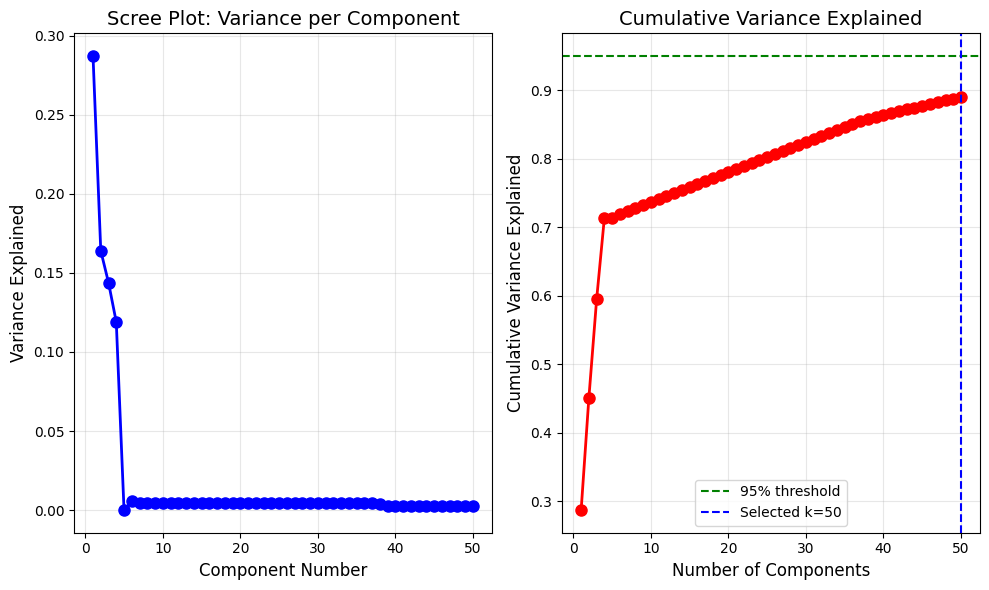


Selected 50 components explaining 89.06% of variance


In [31]:
import matplotlib.pyplot as plt

# Create scree plot
plt.figure(figsize=(10, 6))

# Plot individual variance explained
plt.subplot(1, 2, 1)
plt.plot(range(1, len(svd_probe.explained_variance_ratio_) + 1),
         svd_probe.explained_variance_ratio_,
         'bo-', linewidth=2, markersize=8)
plt.xlabel('Component Number', fontsize=12)
plt.ylabel('Variance Explained', fontsize=12)
plt.title('Scree Plot: Variance per Component', fontsize=14)
plt.grid(True, alpha=0.3)

# Plot cumulative variance explained
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumvar) + 1),
         cumvar,
         'ro-', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
plt.axvline(x=k, color='b', linestyle='--', label=f'Selected k={k}')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance Explained', fontsize=12)
plt.title('Cumulative Variance Explained', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSelected {k} components explaining {cumvar[k-1]*100:.2f}% of variance")